# Walk-Forward Backtest — Sistema Turtle sobre futuros de Bitcoin del CME (IBKR)

**Fuente de reglas:** skill `/turtlerisk` + *The Original Turtle Trading Rules* (Curtis Faith, 2003)
**Validación:** skill `/backtester`
**Universo:** `MBT` (Micro Bitcoin, 0.1 BTC/contrato) y/o `BRR` (Bitcoin, 5 BTC/contrato), CME
**Datos:** Interactive Brokers — `ib.reqHistoricalData` sobre `ContFuture` (serie continua) y
sobre el contrato front-month resuelto por `qsCrypto.ibkr.contracts.front_month`
**Granularidad:** parametrizable de `"1 secs"` a `"1 day"` (§1.2)

Este notebook sigue el template de `Turtle_WalkForward_Diversified.ipynb` y usa **solo**
módulos ya existentes en el proyecto: `qsCrypto.ibkr.config` y `qsCrypto.ibkr.contracts`.
No define clases nuevas ni añade módulos: todo el motor vive en funciones del propio notebook,
igual que en el template.

---

## ⚠️ LEE ESTO ANTES DE INTERPRETAR CUALQUIER RESULTADO

Cambiar de un universo de 50 activos a **un solo subyacente** no es un detalle de
implementación: **rompe la premisa central del sistema Turtle**. Dennis operaba ~20 mercados
descorrelacionados; la ley de los grandes números sobre esas apuestas independientes es lo que
convertía un win-rate del 35% en una curva viable. Con MBT y/o BRR tienes **una sola apuesta**
(§8, sesgo 3: `n_eff ≈ 1`). Espera un drawdown mucho peor y un Sharpe mucho menor que en el
notebook diversificado, y no interpretes la diferencia como un fallo del código.

| # | Sesgo | Impacto | Control en este notebook |
|---|-------|---------|--------------------------|
| 1 | **Roll / serie continua** | 🔴 Severo | `ContFuture` encadena front-months **sin ajustar** el salto de precio en el roll. Ese salto entra al backtest como un retorno que nadie cobró. **Medido** en §8 comparando la continua contra el contrato real en la ventana solapada. |
| 2 | **Look-ahead en canales** | 🟠 Alto | Todos los canales Donchian usan `.shift(1)`. El canal que se evalúa en la barra `t` se construyó con datos hasta `t-1`. Verificado con `assert` en §4. |
| 3 | **Diversificación inexistente** | 🔴 Severo | 1–2 símbolos del **mismo** subyacente. §8 calcula `n_eff` y lo compara con los ~20 mercados del sistema original. |
| 4 | **Costes ignorados** | 🟠 Alto | Comisión **por contrato** y slippage **en ticks** (no en bps): es como se paga un futuro listado. Sin funding — los futuros **no lo pagan**, su carry va en el precio forward. §8 mide la sensibilidad. |
| 5 | **Granularidad vs. horizonte** | 🟠 Alto | Un canal de 55 barras significa 55 **segundos** o 55 **días** según `BAR_SIZE`. §1.2 avisa cuando la combinación no describe una tendencia sino microestructura. |
| 6 | **Profundidad de histórico de IB** | 🟠 Alto | IB no sirve barras sub-30s más allá de ~6 meses. Con `1 secs` la muestra es corta por construcción: pocos regímenes, cero validez estadística. §3 lo reporta. |
| 7 | **Tamaño mínimo de contrato** | 🔴 Severo | El sizing Turtle es continuo; un futuro se opera en **enteros**. Con equity bajo, `floor(qty)=0` y el sistema simplemente no entra. §5 cuenta cuántas entradas se pierden así — un backtest que no lo cuenta te enseña una estrategia que no podrías haber operado. |

**El diagnóstico más importante de este notebook está en §5 (rechazos de entrada) y §8 (n_eff).**
Si el 80% de las señales no se pudieron ejecutar por tamaño de contrato o apalancamiento, el
Sharpe de la curva no describe nada operable.

---

## 1. Setup y configuración

In [24]:
# pip install ib_async pandas numpy matplotlib scipy
import json, math, os, sys, time, warnings, itertools
from datetime import datetime, timezone, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)

plt.rcParams.update({
    "figure.figsize": (14, 6), "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})

# Raíz del repo: se sube hasta encontrar pyproject.toml, así el notebook funciona
# tanto si el kernel arranca en notebooks/ como en la raíz.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))          # para `from qsCrypto...` sin instalar el paquete
CACHE = ROOT / "data_cache" / "ibkr"; CACHE.mkdir(parents=True, exist_ok=True)
OUT = ROOT / "output"; OUT.mkdir(exist_ok=True)

# Únicos módulos del proyecto que se usan (no se añade ninguno):
from qsCrypto.ibkr import config
from qsCrypto.ibkr.contracts import front_month
# Definición autoritativa de MAE/MFE, compartida con el notebook de Parte A y
# con Position. Que el backtest y el bot en vivo midan la excursión con el mismo
# código es lo que hace comparable el test de réplica de §12.
from qsCrypto.portfolio.mae import (
    Excursion, excursions_from_ohlc, mae_star, win_prob_curve, edge_ratio,
    resolvability, flat_bar_mask,
)

print(f"ROOT   : {ROOT}")
print(f"CACHE  : {CACHE}")
print(f"IBKR   : {config.IB_HOST}:{config.IB_PORT} clientId={config.IB_CLIENT_ID} "
      f"account={config.IB_ACCOUNT} mktDataType={config.IB_MARKET_DATA_TYPE}")
print("Setup OK")

ROOT   : /Users/diegoochoa/Projects/qsCrypto
CACHE  : /Users/diegoochoa/Projects/qsCrypto/data_cache/ibkr
IBKR   : 127.0.0.1:7496 clientId=17 account=DU496961 mktDataType=3
Setup OK


### 1.1 Parámetros Turtle

Los canónicos del skill `/turtlerisk`, con una diferencia crítica frente al notebook
diversificado: **aquí se cuentan en BARRAS, no en días**. `ATR_PERIOD = 20` es la EMA-20 del
True Range de la granularidad elegida — 20 segundos, 20 minutos o 20 días. Es la misma fórmula;
lo que cambia es qué llama "N" el sistema.

In [25]:
# ─────────── PARÁMETROS CANÓNICOS TURTLE (skill /turtlerisk) — EN BARRAS ───────────
ATR_PERIOD     = 20       # N = EMA-20 del True Range (en barras de BAR_SIZE)
RISK_PER_UNIT  = 0.01     # 1% del equity por unidad
MAX_UNITS      = 4        # máx. unidades por mercado
STOP_N         = 1.0      # R = 1N. Define la unidad en la que se lee todo el MAE.
ADD_N          = 0.5      # añadir unidad cada ½N
MAX_DIR_UNITS  = 12       # máx. unidades por dirección
MAX_CORR_UNITS = 6        # máx. unidades por grupo correlacionado
MAX_GROSS_LEV  = 4.0      # tope de nocional bruto / equity

# Sistema 1 (corto) / Sistema 2 (largo) — canales Donchian, en BARRAS
SYS1 = {"entry": 20, "exit": 10}
SYS2 = {"entry": 55, "exit": 20}

# ─────────── TRIPLE BARRERA (§5) ───────────
# Sustituye al stop heurístico y a la salida por canal Donchian. Es la misma
# geometría que el etiquetado de López de Prado (AFML cap. 3) con pt_sl = (3, 1),
# aplicada como regla de EJECUCIÓN en vez de como etiqueta.
TAKE_N         = 3.0      # barrera superior: objetivo a +3N = +3R
MAX_HOLD_BARS  = 10       # barrera vertical: 10 barras de 30 min = 5 h
EMBARGO_BARS   = MAX_HOLD_BARS   # el horizonte de la etiqueta fija el embargo (§7)

# Stop inicial de la POBLACIÓN DE CALIBRACIÓN (§8.5). No es el que se opera: es
# el que se usa para observar excursiones. Con un stop de 1N sobreviven tan
# pocos trades que la distribución de MAE de los ganadores queda truncada contra
# el propio stop y el cuantil no tiene sitio donde caer; con 2N sobreviven
# bastantes más y MAE* vuelve a quedar DENTRO de 1R, que es lo que hace que un
# cierre temprano signifique algo. Medido en §8.5.
CALIB_STOP_N   = 2.0

# ─────────── ENTRADA ───────────
# Confirmación: no basta con perforar el canal, la barra SIGUIENTE tiene que
# CERRAR al otro lado. En vivo se ejecuta con una orden marketable en el último
# segundo de la barra de confirmación, así que el fill es su cierre más el cruce
# del spread. Elimina de raíz la ficción del hueco de entrada —ya no se pretende
# llenar a un nivel que quizá nunca se negoció— a cambio de entrar más tarde.
REQUIRE_CONFIRMATION = True

# Umbral de cierre temprano por MAE, DECLARADO ANTES de mirar resultados fuera
# de muestra. Es el único valor que se opera en vivo (Parte A); la versión
# calibrada por fold de §7 existe para responder "¿habría servido adaptarlo?".
#
# El valor NO se elige por rentabilidad —eso sería ajustar a la muestra— sino
# por dos cotas medidas sobre la GEOMETRÍA de las velas, no sobre el P&L:
#   cota inferior: el rango mediano de vela a 30 min es ≈0.76 N, y por debajo de
#                  eso el toque no es distinguible dentro de la propia barra
#                  (§4, `resolvability`). Un umbral irresoluble no es una regla,
#                  es ruido con nombre.
#   cota superior: tiene que quedar ESTRICTAMENTE dentro del stop duro de 1N,
#                  porque si no, no hay "cierre temprano" que valga.
# La banda defendible es por tanto [0.76 N, 1.00 N) y se toma su punto medio.
MAE_STOP_N_FIJO = 0.85

# ─────────── CAPITAL ───────────
# El nocional por contrato de BRR (5 BTC) exige capital de seis cifras; §3 hace
# la comprobación de viabilidad contrato a contrato antes de simular nada.
EQUITY_0 = 275_000

### 1.2 Granularidad — el único parámetro que hay que tocar

`BAR_SIZE` acepta cualquier `barSizeSetting` de IB entre `"1 secs"` y `"1 day"`. De él salen,
sin tocar nada más:

- el **troceado** de las peticiones a `reqHistoricalData` (IB limita la duración por petición
  según el tamaño de barra, y rechaza la petición entera si te pasas),
- la **profundidad** disponible (IB no sirve barras `< 30 secs` más allá de ~6 meses),
- el **factor de anualización** de las métricas — que **no** se asume, se mide sobre el índice
  real de los datos (§3): el CME cierra 1h al día y el fin de semana, así que "barras por año"
  no es `segundos_por_año / segundos_por_barra`,
- las ventanas del walk-forward (§7), expresadas en barras.

**Coherencia horizonte/granularidad:** el sistema Turtle es seguimiento de tendencia. Un canal
de 55 barras de 1 segundo es una ruptura de menos de un minuto: eso es microestructura, y a esa
escala el coste por round-trip (1 tick de slippage + comisión) domina cualquier señal. La celda
avisa cuando la ventana del canal más largo cae por debajo de un día.

In [26]:
# ─────────── GRANULARIDAD ───────────
# 30 min es una elección MEDIDA, no de gusto. Manda la identidad
#     nocional/equity = RISK_PER_UNIT × precio / N
# que no depende del capital: con 1% y BTC≈95.000 hace falta N ≥ 237 puntos para
# caber en MAX_GROSS_LEV=4. Medido sobre el front month de MBT con RTH:
#
#     TF        N (pts)  rango/N  coste/R  nocional/eq
#     1 min        28.8    2.15N      78%       27.7x   inviable
#     5 min        91      1.27N      25%        8.8x   inviable
#     15 min      247      0.50N       9%        3.2x   al límite
#     30 min      424      0.48N       5%        1.9x   ELEGIDA
#     1 hour      684      0.34N       3%        1.2x
#
# A 1 min el coste de ida y vuelta se come el 78% de la R, y eso NO se arregla
# con el tamaño (coste y riesgo por contrato escalan igual): solo subiendo N.
# Y contraintuitivo pero medido: afinar la barra EMPEORA la resolución
# intrabarra (2.15N de rango a 1 min frente a 0.48N a 30 min), porque el TR de
# 1 min lo domina el ruido de tick.
BAR_SIZE     = "30 mins"   # "1 secs".."1 day" — ver IB_BAR_SECONDS
LOOKBACK_DAYS = 365 * 2    # profundidad deseada; se recorta a lo que IB sirva
END_DATETIME  = ""         # "" = ahora; o "20260101 00:00:00 UTC"
# RTH=True es lo que arregla las velas planas del feed demo: medido sobre MBT a
# 1 min, las velas sin rango ni volumen caen del 33% al 0.8% (BRR: 36.5% → 6.6%).
# Una vela plana tiene excursión CERO, así que dejarlas dentro sesga la MAE a la
# baja y hace que cualquier stop parezca más seguro de lo que es.
USE_RTH       = True
WHAT_TO_SHOW  = "TRADES"   # "TRADES" | "MIDPOINT" — MIDPOINT si no hay permisos de trades

# Solape de horario líquido entre los dos contratos: MBT cierra a las 16:00 CT y
# BRR a las 15:15. Recortar ambos a la ventana común deja las dos series con el
# MISMO índice; sin eso, los 45 min en que solo cotiza MBT producen el serrucho
# de mark-to-market que ya conocemos de calendarios heterogéneos.
RTH_OVERLAP = ("13:30", "20:15")   # 08:30–15:15 CT expresado en UTC

# barSizeSetting válidos de IB -> segundos. Es la tabla de la API, no una elección nuestra.
IB_BAR_SECONDS = {
    "1 secs": 1, "5 secs": 5, "10 secs": 10, "15 secs": 15, "30 secs": 30,
    "1 min": 60, "2 mins": 120, "3 mins": 180, "5 mins": 300, "10 mins": 600,
    "15 mins": 900, "20 mins": 1200, "30 mins": 1800,
    "1 hour": 3600, "2 hours": 7200, "3 hours": 10800, "4 hours": 14400,
    "8 hours": 28800, "1 day": 86400,
}
assert BAR_SIZE in IB_BAR_SECONDS, f"BAR_SIZE inválido. Opciones: {list(IB_BAR_SECONDS)}"
BAR_SECONDS = IB_BAR_SECONDS[BAR_SIZE]

def ib_chunk(bar_seconds):
    """(durationStr, segundos) máximos por petición para ese tamaño de barra.

    Los topes son de IB y son duros: una petición que los excede se rechaza entera,
    no se trunca. Van deliberadamente por debajo del límite documentado para dejar
    margen — IB también corta por número de barras devueltas. Es la razón por la que
    §3 pagina sobre contratos reales en vez de pedir la serie entera de una vez.
    """
    for lim, dur, secs in [
        (1,     "1800 S", 1800),      (5,     "3600 S", 3600),
        (30,    "14400 S", 14400),    (60,    "1 D", 86400),
        (300,   "1 W", 7*86400),      (1800,  "1 M", 30*86400),
        (3600,  "2 M", 60*86400),     (86400, "1 Y", 365*86400),
    ]:
        if bar_seconds <= lim:
            return dur, secs
    return "1 Y", 365*86400

def ib_max_history_days(bar_seconds):
    """Hasta dónde atrás sirve IB ese tamaño de barra. None = histórico completo."""
    return 183 if bar_seconds < 30 else None   # sub-30s: ~6 meses

CHUNK_STR, CHUNK_SECONDS = ib_chunk(BAR_SECONDS)
MAX_HIST_DAYS = ib_max_history_days(BAR_SECONDS)
EFFECTIVE_LOOKBACK = min(LOOKBACK_DAYS, MAX_HIST_DAYS or LOOKBACK_DAYS)

print(f"  BAR_SIZE            : {BAR_SIZE}  ({BAR_SECONDS}s por barra)")
print(f"  Petición máx. a IB  : {CHUNK_STR}")
print(f"  Lookback pedido     : {LOOKBACK_DAYS} d")
print(f"  Lookback efectivo   : {EFFECTIVE_LOOKBACK} d"
      + (f"   ⚠ IB no sirve {BAR_SIZE} más allá de ~{MAX_HIST_DAYS} d" if MAX_HIST_DAYS else ""))
print(f"  Peticiones estimadas: ~{math.ceil(EFFECTIVE_LOOKBACK*86400/CHUNK_SECONDS)} por símbolo")

# --- coherencia horizonte / granularidad ---
span_entry_s = SYS2["entry"] * BAR_SECONDS
print(f"\n  Canal largo (Sys2 {SYS2['entry']}b) cubre {span_entry_s/3600:,.2f} h de mercado")
print(f"  Barrera vertical ({MAX_HOLD_BARS}b) cubre {MAX_HOLD_BARS*BAR_SECONDS/3600:,.2f} h")
print(f"  Triple barrera: −{STOP_N:.0f}N / +{TAKE_N:.0f}N / {MAX_HOLD_BARS}b"
      f"  →  pt_sl = ({TAKE_N:.0f}, {STOP_N:.0f}) en notación AFML")
if span_entry_s < 86400:
    print("  ⚠️  El canal de entrada más largo dura MENOS DE UN DÍA de mercado:")
    print("      esto es un sistema de horizonte corto, no seguimiento de tendencia")
    print("      clásico. La tesis de edge de la Parte B tiene que ser coherente con eso.")
else:
    print("  ✓ El canal describe un horizonte de tendencia razonable.")

  BAR_SIZE            : 30 mins  (1800s por barra)
  Petición máx. a IB  : 1 M
  Lookback pedido     : 730 d
  Lookback efectivo   : 730 d
  Peticiones estimadas: ~25 por símbolo

  Canal largo (Sys2 55b) cubre 27.50 h de mercado
  Barrera vertical (10b) cubre 5.00 h
  Triple barrera: −1N / +3N / 10b  →  pt_sl = (3, 1) en notación AFML
  ✓ El canal describe un horizonte de tendencia razonable.


### 1.3 Costes — un futuro listado no se cobra en puntos básicos

Ésta es la diferencia de modelado más importante frente al notebook de perpetuos:

| | Perpetuo cripto | Futuro CME |
|---|---|---|
| Comisión | % del nocional | **USD fijos por contrato** |
| Slippage | bps sobre el precio | **ticks** (`minTick` del contrato) |
| Funding | sí, 3×/día | **no existe** — el carry va en el precio forward |

Cobrar funding a un futuro es un coste inventado que escala con el nocional mientras el sizing
Turtle escala con el riesgo: en instrumentos de N/precio bajo drena la cuenta hasta números
negativos. Aquí `FUNDING = 0` y no es un parámetro que convenga tocar.

Las comisiones por defecto son el orden de magnitud de IBKR (comisión + tasas de bolsa y
clearing, por lado). **Sustitúyelas por las de tu estado de cuenta antes de creerte el
resultado**: a granularidad fina la comisión es el término dominante del P&L.

In [27]:
# Comisión USD por contrato y POR LADO (IBKR + exchange + clearing, aprox.)
# y slippage en TICKS. Ajusta a tu estructura real de comisiones.
COSTS = {
    "MBT": {"comm": 0.62, "slip_ticks": 1.0},
    "BRR": {"comm": 2.75, "slip_ticks": 1.0},
}
FUNDING = 0.0    # los futuros NO pagan funding. No lo cambies.

# A granularidad fina el slippage se paga más veces: el aviso es cuantitativo.
print(f"  Coste round-trip por contrato (con 1 tick de slippage):")
for s, c in COSTS.items():
    print(f"    {s}: 2×{c['comm']:.2f} comisión + 2×{c['slip_ticks']:.0f} tick de slippage")
print("\n  El valor en USD del tick sale de `detail.minTick × multiplier` (§2), no se hardcodea.")

  Coste round-trip por contrato (con 1 tick de slippage):
    MBT: 2×0.62 comisión + 2×1 tick de slippage
    BRR: 2×2.75 comisión + 2×1 tick de slippage

  El valor en USD del tick sale de `detail.minTick × multiplier` (§2), no se hardcodea.


## 2. Universo — MBT / BRR y resolución de contrato

Dos contratos sobre **el mismo subyacente** (el CME CF Bitcoin Reference Rate):

| Símbolo | Contrato | Tamaño | Nocional con BTC a 100k |
|---|---|---|---|
| `MBT` | Micro Bitcoin Futures | 0.1 BTC | ~10.000 USD |
| `BRR` | Bitcoin Futures | 5 BTC | ~500.000 USD |

Están en el **mismo grupo de correlación** (`crypto`), así que el límite de 6 unidades por
grupo del skill los trata como lo que son: una sola apuesta. Operar los dos a la vez no
diversifica nada — solo cambia la granularidad del sizing.

`multiplier` y `minTick` **no se hardcodean**: salen de `reqContractDetails` a través de
`front_month()`, el módulo que ya existe en el repo. Si TWS no está levantado hay un
diccionario de respaldo, marcado como tal en la tabla.

In [28]:
SYMBOLS = ["MBT","BRR"]          # ["MBT"], ["BRR"] o ["MBT", "BRR"]

UNIVERSE = {
    "MBT": {"desc": "Micro Bitcoin Futures (0.1 BTC)", "exchange": "CME", "currency": "USD"},
    "BRR": {"desc": "Bitcoin Futures (5 BTC)",         "exchange": "CME", "currency": "USD"},
}
CORRELATION_GROUPS = {"crypto": {"MBT", "BRR"}}
SYM2GROUP = {s: g for g, ms in CORRELATION_GROUPS.items() for s in ms}

# Respaldo si no hay TWS: especificaciones publicadas del CME. Se usan SOLO si
# reqContractDetails falla, y la tabla de §2 lo marca con `fuente = fallback`.
SPECS_FALLBACK = {
    "MBT": {"multiplier": 0.1, "minTick": 5.0},
    "BRR": {"multiplier": 5.0, "minTick": 5.0},
}

assert all(s in UNIVERSE for s in SYMBOLS), f"SYMBOLS fuera de UNIVERSE: {SYMBOLS}"
assert all(s in SYM2GROUP for s in UNIVERSE)
print(f"{len(SYMBOLS)} símbolo(s) seleccionado(s): {SYMBOLS}")
print(f"⚠️  Ambos comparten subyacente y grupo de correlación → n_eff ≈ 1 (se mide en §8)")

2 símbolo(s) seleccionado(s): ['MBT', 'BRR']
⚠️  Ambos comparten subyacente y grupo de correlación → n_eff ≈ 1 (se mide en §8)


In [29]:
from ib_async import IB, ContFuture, Future, util

# ── OBLIGATORIO EN JUPYTER ────────────────────────────────────────────────
# ib_async es asíncrono por dentro y `ib.connect()` arranca su propio bucle de
# eventos. El kernel de Jupyter YA tiene uno corriendo, así que la llamada muere
# con `RuntimeError: This event loop is already running` — y como `ib_connect()`
# degrada a caché en vez de lanzar, el síntoma aparece cinco celdas más abajo
# como "0 barras", que parece un problema de permisos de datos y no lo es.
#
# `util.startLoop()` (nest_asyncio) permite anidar el bucle y lo arregla. Fuera
# de Jupyter no hace falta y no se llama: en script se usa `util.patchAsyncio()`,
# como hace `qsCrypto/ibkr/check_connection.py`.
def _in_jupyter():
    try:
        return get_ipython().__class__.__name__ == "ZMQInteractiveShell"
    except NameError:
        return False

if _in_jupyter():
    util.startLoop()
    print("  Bucle de eventos parcheado para Jupyter (util.startLoop)")

# TWS reporta los fallos de datos por el canal de errores, NO como excepción:
# `reqHistoricalData` devuelve una lista VACÍA y el motivo real (sin permisos,
# endDateTime mal formado, pacing violation) solo aparece aquí. Sin recogerlos,
# "0 barras" es indistinguible de "el contrato no cotizaba".
IB_ERRORS = []
IB_TIME_OFFSET = pd.Timedelta(0)   # reloj de TWS − reloj local, medido UNA vez

def _on_ib_error(reqId, code, msg, contract):
    # 2104/2106/2158 son avisos de "granja de datos conectada", no errores.
    if code not in (2104, 2106, 2158, 2119):
        IB_ERRORS.append((reqId, code, msg))

def ib_connect(readonly=True, timeout=10):
    """Conecta a TWS/Gateway con los parámetros de `qsCrypto.ibkr.config`.

    Devuelve None en vez de lanzar si no hay sesión: el notebook debe poder
    reejecutarse sobre la caché de §3 sin TWS delante.
    """
    ib = IB()
    try:
        ib.connect(config.IB_HOST, config.IB_PORT, clientId=config.IB_CLIENT_ID,
                   timeout=timeout, readonly=readonly)
    except Exception as e:
        print(f"  ✗ SIN SESIÓN IBKR ({type(e).__name__}: {e})")
        if "event loop is already running" in str(e):
            print("     Causa: el bucle de eventos del kernel no está parcheado.")
            print("     Arreglo: ejecuta `util.startLoop()` (arriba en esta misma celda)")
            print("     ANTES de conectar, o reinicia el kernel y corre las celdas en orden.")
        elif "connection refused" in str(e).lower() or isinstance(e, (ConnectionError, OSError)):
            print(f"     Causa: nadie escucha en {config.IB_HOST}:{config.IB_PORT}.")
            print("     Arreglo: levanta TWS/Gateway y habilita la API "
                  "(Configuración → API → Enable ActiveX and Socket Clients).")
        elif "timeout" in str(e).lower():
            print(f"     Causa: TWS no respondió, o clientId={config.IB_CLIENT_ID} ya está en uso.")
            print("     Arreglo: cambia IB_CLIENT_ID en .env, o acepta el diálogo de "
                  "conexión entrante en TWS.")
        print("  → §3 usará exclusivamente la caché local si existe; si no la hay, corta ahí.")
        return None
    global IB_TIME_OFFSET
    ib.errorEvent += _on_ib_error
    ib.reqMarketDataType(config.IB_MARKET_DATA_TYPE)
    # El reloj de TWS manda: pedir histórico con un endDateTime que para el
    # servidor está en el futuro devuelve vacío sin decir por qué.
    #
    # Se consulta UNA SOLA VEZ y se guarda el desfase. `reqCurrentTime()` se
    # cuelga —o tumba el socket— si se le llama repetidamente en la misma
    # sesión, así que a partir de aquí la hora se deriva con `ib_now()` en vez
    # de volver a preguntar.
    srv = pd.Timestamp(ib.reqCurrentTime())
    IB_TIME_OFFSET = srv - pd.Timestamp.now(tz="UTC")
    print(f"  IBKR conectado — serverVersion {ib.client.serverVersion()}, "
          f"cuentas {ib.managedAccounts()}")
    print(f"  Hora servidor IB: {srv:%Y-%m-%d %H:%M:%S %Z}  |  "
          f"desfase con el reloj local: {IB_TIME_OFFSET.total_seconds():+.1f}s")
    if abs(IB_TIME_OFFSET) > pd.Timedelta(days=1):
        print(f"  ⚠ Desfase de {abs(IB_TIME_OFFSET).days} días entre IB y la máquina. "
              f"§3 usa el de IB.")
    return ib


def ib_now():
    """'Ahora' según el reloj de TWS, sin volver a llamar a `reqCurrentTime()`."""
    return (pd.Timestamp.now(tz="UTC") + IB_TIME_OFFSET).tz_localize(None)

IBS = ib_connect()

Error 326, reqId -1: No es posible conectar ya que id. del cliente se est\u00e1 utilizando. Probar de nuevo con un id. de cliente \u00fanico.


  Bucle de eventos parcheado para Jupyter (util.startLoop)


Peer closed connection. clientId 17 already in use?
API connection failed: TimeoutError()


  ✗ SIN SESIÓN IBKR (TimeoutError: )
     Causa: nadie escucha en 127.0.0.1:7496.
     Arreglo: levanta TWS/Gateway y habilita la API (Configuración → API → Enable ActiveX and Socket Clients).
  → §3 usará exclusivamente la caché local si existe; si no la hay, corta ahí.


In [30]:
def resolve_specs(ib, symbol):
    """multiplier / minTick / front-month del símbolo, vía `front_month()` del repo.

    Se pide el contrato REAL (no la serie continua) porque `ContFuture` no siempre
    trae multiplicador ni tick poblados, y son los dos números de los que dependen
    el sizing (§5) y el coste (§1.3).
    """
    if ib is None:
        fb = SPECS_FALLBACK[symbol]
        return {**fb, "localSymbol": None, "expiry": None, "conId": None, "fuente": "fallback"}
    try:
        contract, detail, expiry = front_month(
            ib, symbol, UNIVERSE[symbol]["exchange"], UNIVERSE[symbol]["currency"])
        mult = float(contract.multiplier) if contract.multiplier else SPECS_FALLBACK[symbol]["multiplier"]
        return {"multiplier": mult, "minTick": float(detail.minTick),
                "localSymbol": contract.localSymbol, "expiry": expiry,
                "conId": contract.conId, "fuente": "IB"}
    except Exception as e:
        print(f"  {symbol}: reqContractDetails falló ({e}); se usa fallback")
        fb = SPECS_FALLBACK[symbol]
        return {**fb, "localSymbol": None, "expiry": None, "conId": None, "fuente": "fallback"}

SPECS = {s: resolve_specs(IBS, s) for s in SYMBOLS}

spec_rows = []
for s, sp in SPECS.items():
    tick_usd = sp["minTick"] * sp["multiplier"]
    spec_rows.append({
        "symbol": s, "desc": UNIVERSE[s]["desc"], "multiplier": sp["multiplier"],
        "minTick": sp["minTick"], "valor_tick_USD": tick_usd,
        "comision_lado_USD": COSTS[s]["comm"],
        "slippage_USD_lado": COSTS[s]["slip_ticks"] * tick_usd,
        "front_month": sp["localSymbol"], "expiry": sp["expiry"], "fuente": sp["fuente"],
    })
SPECS_DF = pd.DataFrame(spec_rows)
display(SPECS_DF)
if (SPECS_DF.fuente == "fallback").any():
    print("⚠️  Especificaciones de respaldo en uso (sin TWS). Verifícalas antes de operar.")

,symbol,desc,multiplier,minTick,valor_tick_USD,comision_lado_USD,slippage_USD_lado,front_month,expiry,fuente
0,MBT,Micro Bitcoin Futures (0.1 BTC),0.1,5.0,0.5,0.62,0.5,None,None,fallback
1,BRR,Bitcoin Futures (5 BTC),5.0,5.0,25.0,2.75,25.0,None,None,fallback


⚠️  Especificaciones de respaldo en uso (sin TWS). Verifícalas antes de operar.


## 3. Descarga de datos — dos fuentes:

IB impone dos restricciones que condicionan todo el diseño de esta sección:

1. **`ContFuture` no admite `endDateTime`.** Pedirlo devuelve el error **10339**
   (*"Setting end date/time for continuous future security type is not allowed"*) y TWS
   **cierra la conexión**. La serie continua solo se puede pedir "hasta ahora", en **una única
   petición**: no hay paginación posible, y la profundidad es la que IB quiera dar.
2. **Los contratos reales sí admiten `endDateTime`**, así que sobre ellos sí se puede paginar
   hacia atrás encadenando peticiones.

Por lo tanto: con `BAR_SIZE = "1 secs"` la petición única de
`ContFuture` devuelve **30 minutos de datos** (el tope por petición para barras de 1 segundo) y
ahí se acaba. La serie continua **no sirve** para granularidad fina.

Por eso `DATA_SOURCE = "chain"` es el valor por defecto: se enumeran los vencimientos con
`includeExpired=True`, se pagina cada uno hacia atrás, y se cosen tomando de cada contrato solo
las barras del periodo en que **fue el front month**. Es más trabajo y más peticiones, pero es la
única fuente que funciona a cualquier granularidad — y además deja las **fechas de roll
explícitas**, que es justo lo que §8 necesita para medir el sesgo de empalme en vez de
adivinarlo con un percentil.

La serie se cose **sin ajustar**: en cada roll hay un salto de precio real que nadie cobró.
No se corrige, se **mide** (§8).

In [31]:
DATA_SOURCE = "chain"   # "chain" (recomendado) | "cont"
ROLL_DAYS   = 2         # se rueda al siguiente vencimiento N días antes de expirar.
                        # Mismo criterio que `front_month(min_days=2)` del repo, para que
                        # el backtest y la resolución de contrato en vivo coincidan.

def _cache_path(symbol, bar_size, kind):
    slug = bar_size.replace(" ", "")
    d = CACHE / slug; d.mkdir(parents=True, exist_ok=True)
    return d / f"{symbol}_{kind}.csv"


def _bars_to_df(bars):
    """BarDataList -> DataFrame OHLCV con índice UTC tz-naive y columnas en minúscula."""
    if not bars:
        return pd.DataFrame()
    df = util.df(bars)
    if df is None or not len(df):
        return pd.DataFrame()
    df = df.rename(columns={"date": "time"})
    idx = pd.to_datetime(df["time"], utc=True, errors="coerce").dt.tz_localize(None)
    df = df.assign(time=idx).dropna(subset=["time"]).set_index("time").sort_index()
    keep = [c for c in ("open", "high", "low", "close", "volume") if c in df.columns]
    return df[keep].astype(float)


def _fmt_end(ts):
    """endDateTime en el formato que TWS 10.x acepta sin ambigüedad de zona.

    Un `datetime` naive se rechaza (error 10314) y la llamada devuelve [] en
    silencio; el string UTC explícito no depende de la zona de la máquina.
    """
    return pd.Timestamp(ts).strftime("%Y%m%d-%H:%M:%S")

Data fetcher para las velas/barras de los contratos, las cadenas enteras (curva)
o para la serie continua de IBKR.

In [32]:
def fetch_contract_bars(ib, contract, bar_size, start_ts, end_ts,
                        max_requests=200, pacing=0.6, timeout=25, verbose=False):
    """Histórico de UN contrato real, paginando hacia atrás desde `end_ts`.

    Solo para `Future` con vencimiento concreto: `ContFuture` rechaza
    `endDateTime` (error 10339) y además tumba la conexión. Pendiente error handler para 
    este caso 
    """
    chunk_str, chunk_secs = ib_chunk(IB_BAR_SECONDS[bar_size])
    frames, cursor, n_req = [], pd.Timestamp(end_ts), 0

    while cursor > pd.Timestamp(start_ts) and n_req < max_requests:
        n_err0 = len(IB_ERRORS)
        try:
            bars = ib.reqHistoricalData(
                contract, endDateTime=_fmt_end(cursor), durationStr=chunk_str,
                barSizeSetting=bar_size, whatToShow=WHAT_TO_SHOW,
                useRTH=USE_RTH, formatDate=2, timeout=timeout)
        except Exception as e:
            if verbose: print(f"      petición {n_req+1} falló ({e})")
            break
        n_req += 1
        chunk = _bars_to_df(bars)
        if not len(chunk):
            if verbose:
                nuevos = IB_ERRORS[n_err0:]
                if nuevos: print(f"      vacío en {cursor:%Y-%m-%d}: "
                                 + "; ".join(f"[{c}] {m}" for _, c, m in nuevos))
            break
        frames.append(chunk)
        nueva = chunk.index[0]
        # Sin este guard, un chunk que empieza donde empezó el anterior deja el
        # bucle girando hasta max_requests sin añadir una sola barra nueva.
        if nueva >= cursor:
            break
        cursor = nueva
        ib.sleep(pacing)

    if not frames:
        return pd.DataFrame(), n_req
    df = (pd.concat(frames).sort_index()
            .loc[lambda d: ~d.index.duplicated(keep="last")])
    return df, n_req


def fetch_chain(ib, symbol, bar_size, lookback_days, verbose=True):
    """Serie continua cosida a partir de los vencimientos REALES.

    De cada contrato se toman solo las barras del periodo en que fue el front
    month —desde el roll del anterior hasta el suyo propio— así que no hay
    solapamiento y el empalme ocurre exactamente en `ROLL_DAYS` antes de cada
    vencimiento. Devuelve (df, tabla_de_rolls).
    """
    det = ib.reqContractDetails(Future(symbol=symbol, exchange=UNIVERSE[symbol]["exchange"],
                                       currency=UNIVERSE[symbol]["currency"],
                                       includeExpired=True))
    if not det:
        return pd.DataFrame(), pd.DataFrame()

    chain = sorted(
        ((pd.Timestamp(d.contract.lastTradeDateOrContractMonth[:8]), d.contract) for d in det),
        key=lambda t: t[0])
    now = ib_now()
    horizon = now - pd.Timedelta(days=lookback_days)

    piezas, rolls, prev_roll, total_req = [], [], None, 0
    for expiry, c in chain:
        roll = expiry - pd.Timedelta(days=ROLL_DAYS)
        ini = prev_roll if prev_roll is not None else roll - pd.Timedelta(days=400)
        fin = min(roll, now)
        prev_roll = roll
        if fin <= horizon or ini >= fin:      # tramo fuera de la ventana pedida
            continue
        ini = max(ini, horizon)
        if verbose:
            print(f"    {c.localSymbol:<10} pidiendo {ini:%Y-%m-%d} → {fin:%Y-%m-%d} ...",
                  end="", flush=True)
        t0 = time.time()
        df, n_req = fetch_contract_bars(ib, c, bar_size, ini, fin)
        total_req += n_req
        tramo = (df.loc[(df.index >= ini) & (df.index <= fin)] if len(df) else df)
        if not len(tramo):
            # Un vencimiento sin datos no es un fallo: IB no guarda histórico de
            # todos los contratos expirados, y los muy antiguos o poco líquidos
            # simplemente no responden. Se salta y se sigue cosiendo.
            if verbose:
                print(f" sin datos ({n_req} pet., {time.time()-t0:.0f}s)")
            continue
        if verbose:
            print(f" {len(tramo):>6} barras ({n_req} pet., {time.time()-t0:.0f}s)")
        piezas.append(tramo)
        rolls.append({"contrato": c.localSymbol, "expiry": expiry.date(),
                      "roll": roll.date(), "desde": tramo.index[0], "hasta": tramo.index[-1],
                      "barras": len(tramo), "ultimo_close": float(tramo["close"].iloc[-1])})
    if not piezas:
        return pd.DataFrame(), pd.DataFrame()
    df = (pd.concat(piezas).sort_index()
            .loc[lambda d: ~d.index.duplicated(keep="last")])
    if verbose:
        print(f"    → {len(piezas)} contratos cosidos, {total_req} peticiones en total")
    return df, pd.DataFrame(rolls)


def fetch_cont(ib, symbol, bar_size, verbose=True):
    """Serie continua de IB — UNA petición, sin `endDateTime`.

    `ContFuture` + `endDateTime` = error 10339 y desconexión, así que aquí no hay
    paginación posible: la profundidad es la que IB decida servir. Con barras
    sub-minuto eso son minutos de datos, no años.
    """
    cf = ContFuture(symbol=symbol, exchange=UNIVERSE[symbol]["exchange"],
                    currency=UNIVERSE[symbol]["currency"])
    try:
        cf = ib.qualifyContracts(cf)[0]
    except Exception as e:
        return pd.DataFrame(), f"qualifyContracts falló: {e}"
    dur, _ = ib_chunk(IB_BAR_SECONDS[bar_size])
    if IB_BAR_SECONDS[bar_size] >= 3600:
        dur = "10 Y"          # IB recorta solo a lo que tenga; pedir de más no penaliza
    bars = ib.reqHistoricalData(cf, endDateTime="", durationStr=dur,
                                barSizeSetting=bar_size, whatToShow=WHAT_TO_SHOW,
                                useRTH=USE_RTH, formatDate=2, timeout=60)
    return _bars_to_df(bars), f"CONTFUT 1 petición ({dur})"


def fetch_bars(ib, symbol, bar_size=None, lookback_days=None, source=None, use_cache=True):
    """Dispatcher con caché. Devuelve (df, tabla_rolls, nota)."""
    bar_size = bar_size or BAR_SIZE
    lookback_days = lookback_days or EFFECTIVE_LOOKBACK
    source = source or DATA_SOURCE
    path, rpath = _cache_path(symbol, bar_size, source), _cache_path(symbol, bar_size, f"{source}_rolls")

    if use_cache and path.exists():
        df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
        rolls = (pd.read_csv(rpath, parse_dates=["desde", "hasta"])
                 if rpath.exists() else pd.DataFrame())
        if len(df):
            return df, rolls, f"caché ({path.name})"

    if ib is None:
        return pd.DataFrame(), pd.DataFrame(), "sin sesión IBKR y sin caché"

    if source == "chain":
        df, rolls = fetch_chain(ib, symbol, bar_size, lookback_days)
        nota = f"cadena de vencimientos ({len(rolls)} contratos)"
    else:
        df, nota = fetch_cont(ib, symbol, bar_size)
        rolls = pd.DataFrame()

    if not len(df):
        return df, rolls, nota
    df = df.dropna(subset=["open", "high", "low", "close"])
    df = df[(df[["open", "high", "low", "close"]] > 0).all(axis=1)]
    df.to_csv(path)
    if len(rolls):
        rolls.to_csv(rpath, index=False)
    return df, rolls, f"{nota} → {path.name}"

In [33]:
def trim_to_overlap(df, window=None):
    """Recorta al horario líquido común a MBT y BRR.

    IB ya filtra por RTH, pero el RTH de cada contrato es distinto (MBT hasta
    las 16:00 CT, BRR hasta las 15:15). Sin este recorte los 45 min en que solo
    cotiza MBT quedan como barras donde una pata del libro se marca a mercado y
    la otra no: un serrucho en la curva de equity que no es del mercado.
    """
    window = window or RTH_OVERLAP
    if not window:
        return df
    return df.between_time(window[0], window[1], inclusive="left")


RAW, ROLLS, ERR = {}, {}, {}
_min_bars = max(ATR_PERIOD + SYS2["entry"] + 10, 120)

for s in SYMBOLS:
    print(f"  {s} ({DATA_SOURCE}):")
    df, rolls, nota = fetch_bars(IBS, s)
    n_raw = len(df)
    if n_raw:
        df = trim_to_overlap(df)
    if len(df) >= _min_bars:
        RAW[s], ROLLS[s] = df, rolls
        flat_pct = flat_bar_mask(df).mean()
        print(f"  {s:<5} {len(df):>7,} barras  "
              f"{df.index[0]:%Y-%m-%d %H:%M} → {df.index[-1]:%Y-%m-%d %H:%M}  [{nota}]  ✓")
        print(f"        recorte al solape {RTH_OVERLAP[0]}–{RTH_OVERLAP[1]} UTC: "
              f"{n_raw:,} → {len(df):,} barras | velas planas {flat_pct:.1%}")
        if flat_pct > 0.05:
            print(f"        ⚠ {flat_pct:.1%} de velas sin rango ni volumen. Con RTH lo "
                  f"esperado es ~1%; por encima, la MAE queda infravalorada.")
    else:
        ERR[s] = f"{len(df)} barras (< {_min_bars} necesarias) — {nota}"
        print(f"  {s:<5} descartado — {ERR[s]}")

# Índice común: los dos contratos son el MISMO subyacente y el motor los marca a
# mercado en las mismas barras. Alinearlos aquí evita tener que hacerlo en cada
# sitio que recorre `RAW`.
if len(RAW) > 1:
    common = None
    for d in RAW.values():
        common = d.index if common is None else common.intersection(d.index)
    RAW = {s: d.loc[common] for s, d in RAW.items()}
    print(f"\n  Índice común a {len(RAW)} contratos: {len(common):,} barras")

if not RAW:
    print("\n  Diagnóstico — últimos errores de TWS:")
    for r, c, m in IB_ERRORS[-8:]:
        print(f"    reqId {r} [{c}] {m}")
assert RAW, ("Ningún símbolo con datos. Levanta TWS/Gateway (revisa IB_PORT en .env), "
             "comprueba los permisos de datos de futuros CME, o ejecuta antes con "
             "conexión para poblar la caché.")

  MBT (chain):
  MBT     4,354 barras  2025-04-25 15:00 → 2026-09-04 20:00  [caché (MBT_chain.csv)]  ✓
        recorte al solape 13:30–20:15 UTC: 4,848 → 4,354 barras | velas planas 8.4%
        ⚠ 8.4% de velas sin rango ni volumen. Con RTH lo esperado es ~1%; por encima, la MAE queda infravalorada.
  BRR (chain):
  BRR     4,313 barras  2025-01-31 19:30 → 2026-09-04 20:00  [caché (BRR_chain.csv)]  ✓
        recorte al solape 13:30–20:15 UTC: 4,503 → 4,313 barras | velas planas 8.3%
        ⚠ 8.3% de velas sin rango ni volumen. Con RTH lo esperado es ~1%; por encima, la MAE queda infravalorada.

  Índice común a 2 contratos: 4,187 barras


In [34]:
# Factor de anualización MEDIDO, no asumido. El CME cierra 1h al día y el fin de
# semana: `segundos_por_año / BAR_SECONDS` sobreestima las barras reales entre un
# 30% y un 40% y, como Sharpe = CAGR/vol y vol escala con √barras, infla el Sharpe
# ~1.2x. Se mide sobre el propio índice.
_ref = RAW[SYMBOLS[0]] if SYMBOLS[0] in RAW else next(iter(RAW.values()))
_span_days = max((_ref.index[-1] - _ref.index[0]).total_seconds() / 86400, 1e-9)
BARS_PER_YEAR = len(_ref) / _span_days * 365.25
BARS_PER_DAY  = len(_ref) / _span_days
_teorico = 365.25 * 86400 / BAR_SECONDS

print(f"  Muestra              : {_span_days:,.1f} días de calendario, {len(_ref):,} barras")
print(f"  Barras/día (medido)  : {BARS_PER_DAY:,.2f}")
print(f"  Barras/año (medido)  : {BARS_PER_YEAR:,.0f}")
print(f"  Barras/año (teórico) : {_teorico:,.0f}  → el teórico sobreestima "
      f"{_teorico/BARS_PER_YEAR:.2f}x")
print(f"  Años de muestra      : {_span_days/365.25:.2f}")
if _span_days / 365.25 < 2:
    print("  ⚠️  Menos de 2 años de muestra: insuficiente para seguimiento de tendencia.")
    print("      MBT y BRR son contratos jóvenes y el histórico que sirve IB para ellos")
    print("      es corto por construcción. No es un fallo de la descarga: es el límite")
    print("      real de la evidencia disponible, y §10 lo penaliza en el checklist.")

INV = pd.DataFrame([
    {"symbol": s, "inicio": d.index[0], "fin": d.index[-1], "barras": len(d),
     "años": round((d.index[-1]-d.index[0]).total_seconds()/86400/365.25, 2),
     "contratos": len(ROLLS.get(s, [])),
     "precio_ini": d["close"].iloc[0], "precio_fin": d["close"].iloc[-1]}
    for s, d in RAW.items()])
display(INV)

for s, r in ROLLS.items():
    if len(r):
        print(f"\n  Contratos cosidos en {s}:")
        display(r)

  Muestra              : 487.2 días de calendario, 4,187 barras
  Barras/día (medido)  : 8.59
  Barras/año (medido)  : 3,139
  Barras/año (teórico) : 17,532  → el teórico sobreestima 5.58x
  Años de muestra      : 1.33
  ⚠️  Menos de 2 años de muestra: insuficiente para seguimiento de tendencia.
      MBT y BRR son contratos jóvenes y el histórico que sirve IB para ellos
      es corto por construcción. No es un fallo de la descarga: es el límite
      real de la evidencia disponible, y §10 lo penaliza en el checklist.


,symbol,inicio,fin,barras,años,contratos,precio_ini,precio_fin
0,MBT,2025-05-05 16:00:00,2026-09-04 20:00:00,4187,1.33,13,96685.0,80045.0
1,BRR,2025-05-05 16:00:00,2026-09-04 20:00:00,4187,1.33,13,96550.0,80115.0



  Contratos cosidos en MBT:


,contrato,expiry,roll,desde,hasta,barras,ultimo_close
0,MBTU5,2025-09-26,2025-09-24,2025-04-25 15:00:00,2025-09-23 20:30:00,1262,112050.0
1,MBTV5,2025-10-31,2025-10-29,2025-09-24 13:30:00,2025-10-28 20:30:00,375,112915.0
2,MBTX5,2025-11-28,2025-11-26,2025-10-29 13:30:00,2025-11-25 21:30:00,300,87030.0
3,MBTZ5,2025-12-26,2025-12-24,2025-11-26 14:30:00,2025-12-23 21:30:00,277,87655.0
4,MBTF6,2026-01-30,2026-01-28,2025-12-24 14:30:00,2026-01-27 21:30:00,339,89100.0
5,MBTG6,2026-02-27,2026-02-25,2026-01-28 14:30:00,2026-02-24 21:30:00,285,64105.0
6,MBTH6,2026-03-27,2026-03-25,2026-02-25 14:30:00,2026-03-24 20:30:00,300,70115.0
7,MBTJ6,2026-04-24,2026-04-22,2026-03-25 13:30:00,2026-04-21 20:30:00,285,75735.0
8,MBTK6,2026-05-29,2026-05-27,2026-04-22 13:30:00,2026-05-26 20:30:00,360,75960.0
9,MBTM6,2026-06-26,2026-06-24,2026-05-27 13:30:00,2026-06-23 20:30:00,285,62385.0



  Contratos cosidos en BRR:


,contrato,expiry,roll,desde,hasta,barras,ultimo_close
0,BTCU5,2025-09-26,2025-09-24,2025-01-27 20:30:00,2025-09-23 20:00:00,1155,111970.0
1,BTCV5,2025-10-31,2025-10-29,2025-09-24 13:30:00,2025-10-28 20:00:00,350,112975.0
2,BTCX5,2025-11-28,2025-11-26,2025-10-29 13:30:00,2025-11-25 21:00:00,280,87200.0
3,BTCZ5,2025-12-26,2025-12-24,2025-11-26 14:30:00,2025-12-23 21:00:00,259,87645.0
4,BTCF6,2026-01-30,2026-01-28,2025-12-24 14:30:00,2026-01-27 21:00:00,317,89375.0
5,BTCG6,2026-02-27,2026-02-25,2026-01-28 14:30:00,2026-02-24 21:00:00,266,64330.0
6,BTCH6,2026-03-27,2026-03-25,2026-02-25 14:30:00,2026-03-24 20:00:00,280,69400.0
7,BTCJ6,2026-04-24,2026-04-22,2026-03-25 13:30:00,2026-04-21 20:00:00,266,75580.0
8,BTCK6,2026-05-29,2026-05-27,2026-04-22 13:30:00,2026-05-26 20:00:00,336,75985.0
9,BTCM6,2026-06-26,2026-06-24,2026-05-27 13:30:00,2026-06-23 20:00:00,266,62430.0


In [35]:
# Viabilidad: ¿se puede operar UN contrato con este capital?
# El sizing Turtle es continuo pero un futuro se compra entero. Si un solo
# contrato ya excede el tope de apalancamiento, el sistema no entra 
# y la curva de equity sale plana.
print("="*74); print("  VIABILIDAD DE CAPITAL"); print("="*74)
for s, d in RAW.items():
    px = float(d["close"].iloc[-1]); mult = SPECS[s]["multiplier"]
    notional = px * mult
    print(f"\n  {s}: precio {px:,.0f} × {mult} = {notional:,.0f} USD de nocional por contrato")
    print(f"     Nocional máx. permitido ({MAX_GROSS_LEV}x sobre {EQUITY_0:,}): "
          f"{MAX_GROSS_LEV*EQUITY_0:,.0f} USD → {int(MAX_GROSS_LEV*EQUITY_0//notional)} contratos")
    if notional > MAX_GROSS_LEV * EQUITY_0:
        print(f"     ✗ NI UN CONTRATO cabe. Sube EQUITY_0 (mínimo ≈ "
              f"{notional/MAX_GROSS_LEV:,.0f}) o cambia a MBT.")
    else:
        n_riesgo = RISK_PER_UNIT * EQUITY_0
        print(f"     Riesgo por unidad ({RISK_PER_UNIT:.0%} de equity): {n_riesgo:,.0f} USD "
              f"→ hace falta N ≤ {n_riesgo/mult:,.0f} para que floor(qty) ≥ 1")

  VIABILIDAD DE CAPITAL

  MBT: precio 80,045 × 0.1 = 8,004 USD de nocional por contrato
     Nocional máx. permitido (4.0x sobre 275,000): 1,100,000 USD → 137 contratos
     Riesgo por unidad (1% de equity): 2,750 USD → hace falta N ≤ 27,500 para que floor(qty) ≥ 1

  BRR: precio 80,115 × 5.0 = 400,575 USD de nocional por contrato
     Nocional máx. permitido (4.0x sobre 275,000): 1,100,000 USD → 2 contratos
     Riesgo por unidad (1% de equity): 2,750 USD → hace falta N ≤ 550 para que floor(qty) ≥ 1


## 4. Indicadores — N y canales Donchian

`N` es la EMA-`ATR_PERIOD` del True Range con la fórmula exacta del documento original:
`N = (19 × PDN + TR) / 20`, sembrada con la SMA de los primeros 20 TR. Idéntica al notebook
diversificado: lo único que cambia es que la "barra" ya no es necesariamente un día.

**Todos los canales llevan `.shift(1)`.** El canal que se evalúa en la barra `t` se construyó
con datos hasta el cierre de `t-1`. Sin esto el backtest "ve" el máximo de la propia barra en la
que opera y el resultado es fantasía.

Un detalle propio de los futuros: `N` está en **puntos de precio**, y el riesgo en USD es
`N × multiplier`. Con MBT (0.1) un N de 2.000 USD/BTC son 200 USD de riesgo por contrato; con
BRR (5.0) son 10.000. Es el mismo N y son dos posiciones completamente distintas.

In [36]:
def compute_n(df, period=ATR_PERIOD):
    """N = EMA-{period} del True Range (fórmula Turtle exacta), en puntos de precio."""
    h, l, c = df["high"].values, df["low"].values, df["close"].values
    pdc = np.roll(c, 1); pdc[0] = c[0]
    tr = np.maximum(h - l, np.maximum(np.abs(h - pdc), np.abs(pdc - l)))
    n = np.full(len(tr), np.nan)
    if len(tr) < period:
        return n
    n[period - 1] = tr[:period].mean()                         # semilla SMA
    for i in range(period, len(tr)):
        n[i] = ((period - 1) * n[i - 1] + tr[i]) / period       # update EMA
    return n


def prepare(df, entry_bars, exit_bars):
    """Añade N, canales Donchian y calidad de barra. shift(1) ⇒ sin look-ahead."""
    d = df.copy()
    d["n"] = compute_n(d)
    d["ent_hi"]  = d["high"].rolling(entry_bars).max().shift(1)
    d["ent_lo"]  = d["low"].rolling(entry_bars).min().shift(1)
    d["exit_hi"] = d["high"].rolling(exit_bars).max().shift(1)
    d["exit_lo"] = d["low"].rolling(exit_bars).min().shift(1)

    # Calidad de barra: una vela sin rango ni volumen no puede tocar ninguna
    # barrera horizontal, y su excursión es cero por construcción.
    d["flat"] = flat_bar_mask(d)

    # Resolución intrabarra: rango típico de vela medido en N. Si el umbral de
    # MAE cae por debajo de esto, el toque no es distinguible DENTRO de la vela
    # y el backtest estaría inventando un orden de eventos que no observó.
    # shift(1) también aquí: es una magnitud de decisión como cualquier otra.
    _rng = (d["high"] - d["low"]).where(~d["flat"])
    d["rng_med"] = _rng.rolling(ATR_PERIOD, min_periods=5).median().shift(1)
    d["rng_n"]   = d["rng_med"] / d["n"]

    return d.dropna(subset=["n", "ent_hi", "ent_lo", "exit_hi", "exit_lo"])


# Identidad de sizing del skill, adaptada al futuro: qty × N × multiplier = 1% × equity
for n_pts, mult in [(2000, 0.1), (2000, 5.0), (35, 0.1)]:
    qty = (RISK_PER_UNIT * EQUITY_0) / (n_pts * mult)
    assert abs(qty * n_pts * mult - EQUITY_0 * RISK_PER_UNIT) < 1e-6
print("✓ Identidad verificada: Qty × N × multiplier = 1% × equity")

# Anti-look-ahead
_s = next(iter(RAW))
_t = prepare(RAW[_s], 20, 10)
_manual = RAW[_s]["high"].rolling(20).max().shift(1).reindex(_t.index)
assert np.allclose(_t["ent_hi"], _manual, equal_nan=True)
print("✓ Canales verificados: shift(1) aplicado, sin look-ahead")

✓ Identidad verificada: Qty × N × multiplier = 1% × equity
✓ Canales verificados: shift(1) aplicado, sin look-ahead


## 5. Motor de backtest

Mismas reglas del skill que el notebook diversificado, con cuatro adaptaciones obligadas por
operar un futuro listado en vez de un perpetuo:

1. **Contratos enteros.** `qty = floor(risk × equity / (N × multiplier))`. Si sale 0, la señal
   existe pero **no se puede ejecutar**. El motor lo cuenta en `REJECTS` en lugar de fingir una
   fracción de contrato — es la diferencia entre un backtest y un folleto.
2. **Slippage en ticks.** El fill se desplaza `slip_ticks × minTick` en contra, y se redondea a
   `minTick`: no existen precios entre ticks.
3. **Comisión por contrato**, cobrada en entrada, en cada add y en la salida.
4. **Sin funding.** `FUNDING = 0`; el término sigue en la firma solo para poder demostrar en §8
   que activarlo es un coste inventado.

Se mantiene el resto: adds cada ½N con **todos** los stops recolocados al nuevo fill, salida por
canal contrario de la posición **completa**, límites 4/mercado – 6/grupo – 12/dirección, regla de
drawdown (−10% de equity ⇒ −20% de nocional) y tope de apalancamiento bruto.

**Orden de prelación intrabarra (conservador):** si en la misma barra se tocan stop y canal de
salida, se asume que se ejecutó el **stop**. Sin datos por debajo de la granularidad elegida no
sabemos qué ocurrió primero, y equivocarse a favor del sistema es exactamente cómo se construyen
backtests mentirosos. Ojo: esta suposición pesa mucho más con `1 day` que con `1 min`, y es una
razón real para bajar la granularidad.

In [37]:
def new_position(side, qty, fill, n_entry, stop, t, r_pts=None, rng_n0=np.nan):
    """Posición como dict — el motor no define clases (ver cabecera del notebook).

    'units' es la lista de fills [(contratos, precio)]; el resto se deriva con
    `pos_qty` / `pos_cost` / `pos_nu` para no duplicar estado que pueda desincronizarse.

    `entry0` y `r_pts` se congelan en la entrada: los adds mueven el ancla del
    stop, pero la excursión de un trade se mide contra donde ese trade empezó.
    Sin congelarlos, una pirámide reescribiría hacia atrás una MAE ya observada.
    `exc` es el acumulador de qsCrypto.portfolio.mae, la definición autoritativa.
    """
    r_pts = n_entry * STOP_N if r_pts is None else r_pts
    return {"side": side, "units": [(qty, fill)], "stop": stop,
            "last_fill": fill, "n_entry": n_entry, "opened": t,
            "entry0": fill, "r_pts": r_pts, "qty0": qty, "rng_n0": rng_n0,
            "exc": Excursion(side=side, anchor0=fill, n0=n_entry, r0=r_pts)}

def pos_qty(p):  return sum(u[0] for u in p["units"])          # contratos
def pos_cost(p): return sum(u[0]*u[1] for u in p["units"])     # Σ contratos×precio (puntos)
def pos_nu(p):   return len(p["units"])                        # unidades Turtle


def adjusted_notional(start_eq, cur_eq):
    """Regla Turtle: cada −10% de equity ⇒ nocional −20%."""
    notional, dd = start_eq, start_eq - cur_eq
    while dd >= notional * 0.10 and notional > start_eq * 0.05:
        dd -= notional * 0.10
        notional *= 0.80
    return notional


def round_tick(px, tick):
    """Los precios existen solo en múltiplos de minTick."""
    return round(px / tick) * tick if tick else px

In [38]:
def run_turtle(data, entry_bars, exit_bars, stop_n=STOP_N, risk=RISK_PER_UNIT,
               equity0=EQUITY_0, max_units=MAX_UNITS, allow_short=True,
               use_dd_rule=True, costs=None, specs=None, funding=FUNDING,
               max_gross_lev=MAX_GROSS_LEV, start=None, end=None,
               open_book=None, rejects=None,
               # ─────────── triple barrera (§5) ───────────
               mae_stop_n=None,          # barrera inferior en N. None ⇒ stop_n (legado)
               take_n=None,              # barrera superior en N. None ⇒ sin objetivo
               max_hold_bars=None,       # barrera vertical en BARRAS. None ⇒ sin límite
               use_donchian_exit=True,   # False ⇒ triple barrera pura
               tie_break="pessimistic",  # "pessimistic" | "optimistic"
               require_confirmation=True,  # entrar solo si la barra SIGUIENTE confirma
               sizing_equity="mark",     # "mark" (legado) | "fixed" (calibración)
               diag=None):
    """Backtest Turtle sobre futuros del CME. Devuelve (equity_curve, trades).

    `data`   : {símbolo: df con columnas de `prepare()`}
    `costs`  : {símbolo: {"comm": USD/contrato/lado, "slip_ticks": ticks}}
    `specs`  : {símbolo: {"multiplier": ..., "minTick": ...}}
    `rejects`: dict opcional; si se pasa, se rellena con el recuento de señales
               NO ejecutadas por motivo. Sin esto no hay forma de distinguir "el
               sistema no dio señales" de "el sistema no pudo operarlas" — y con
               contratos enteros el segundo caso es la norma, no la excepción.
    `open_book`: dict opcional con el libro vivo en la última barra simulada
               (posiciones, último cierre y cash), que no aparece ni en la curva
               ni en `trades` porque `trades` solo contiene operaciones cerradas.
    """
    costs = costs or COSTS
    specs = specs or SPECS
    data = {s: (d.loc[start:end] if (start is not None or end is not None) else d)
            for s, d in data.items()}
    data = {s: d for s, d in data.items() if len(d) > 5}
    if not data:
        return pd.Series(dtype=float), pd.DataFrame()

    rej = {"sin_N": 0, "qty_cero": 0, "apalancamiento": 0,
           "limite_direccion": 0, "limite_grupo": 0, "ejecutadas": 0, "adds_qty_cero": 0,
           "pendientes": 0, "sin_confirmar": 0}
    dg = {"barras_ambiguas": 0}
    sn = stop_n if mae_stop_n is None else mae_stop_n   # barrera inferior efectiva

    bars = sorted(set().union(*[set(d.index) for d in data.values()]))
    equity, pos, curve, trades = float(equity0), {}, [], []
    pending = {}      # rupturas a la espera de la barra de confirmación
    last_close = {}

    def _mark():
        """(nocional bruto, equity marcado a mercado) ahora mismo, en USD."""
        g = sum(pos_qty(p) * last_close[s] * specs[s]["multiplier"] for s, p in pos.items())
        e = equity + sum(p["side"] * (last_close[s]*pos_qty(p) - pos_cost(p))
                         * specs[s]["multiplier"] for s, p in pos.items())
        return g, e

    def _fits_leverage(add_notional):
        """¿Cabe una unidad más sin pasar el tope de nocional bruto / equity?

        El sizing Turtle fija el RIESGO (1%·equity/N), no el nocional: cuanto menor
        es N/precio, más nocional compra ese 1%. A granularidad fina N cae mucho más
        rápido que el precio, así que sin este tope una barra de 1 minuto pide
        cientos de contratos de BRR sobre una cuenta de seis cifras.
        """
        if max_gross_lev is None:
            return True
        g, e = _mark()
        if e <= 0:
            return False
        return g + add_notional <= max_gross_lev * e

    for t in bars:
        for s, d in data.items():
            if t in d.index:
                last_close[s] = d.at[t, "close"]

        # ---- 0) funding — cero en futuros; el bloque queda para poder medirlo en §8 ----
        if pos and funding:
            equity -= funding * sum(pos_qty(p) * last_close[s] * specs[s]["multiplier"]
                                    for s, p in pos.items())

        # nocional ajustado por drawdown (marca previa a las salidas de esta barra)
        upnl0 = sum(p["side"] * (last_close[s]*pos_qty(p) - pos_cost(p)) * specs[s]["multiplier"]
                    for s, p in pos.items())
        if sizing_equity == "fixed":
            # La corrida de observación (sin stop) hunde la curva por construcción;
            # dejar que el tamaño reaccione a eso lo llevaría al suelo del 5% y la
            # muestra de calibración desaparecería en silencio.
            eq_size = equity0
        else:
            eq_size = (adjusted_notional(equity0, equity + upnl0) if use_dd_rule
                       else equity + upnl0)
        eq_size = max(eq_size, equity0 * 0.05)

        # ---- 1) salidas: TRIPLE BARRERA (−mae_stop_n·N / +take_n·N / max_hold_bars) ----
        # Prelación intrabarra, deliberadamente PESIMISTA (pitfalls.md:71):
        #   0. hueco de apertura   → el nivel ya está superado al abrir, sin ambigüedad
        #   1. stop y objetivo en la MISMA barra → gana el adverso; la barra se
        #      marca AMBIGUA y se cuenta, porque su P&L es un artefacto de esta regla
        #   2. stop  3. objetivo  4. canal Donchian  5. vencimiento (al cierre)
        for s in list(pos):
            if t not in data[s].index:
                continue
            r, p = data[s].loc[t], pos[s]
            sd = p["side"]
            mult, tick = specs[s]["multiplier"], specs[s]["minTick"]
            slip = costs[s]["slip_ticks"] * tick
            flat = bool(r.get("flat", False))
            exc = p["exc"]

            # (a) la excursión se actualiza SIEMPRE, antes de decidir nada
            exc.update_bar(r["high"], r["low"], flat=flat)

            # (b) barreras en precio. El stop sigue al ancla viva (regla Turtle de
            #     subir stops en cada add); el objetivo queda anclado en la entrada,
            #     porque un objetivo es del trade y no del último add.
            stop_px, take_px = exc.barrier_prices(sn, take_n)
            p["stop"] = stop_px
            expired = (max_hold_bars is not None and exc.bars >= max_hold_bars)

            # (c) toques. Una vela PLANA no tiene rango observable: no puede tocar
            #     nada horizontal, solo dejar correr el reloj de la vertical.
            if flat:
                hit_stop = hit_take = hit_don = False
            elif sd > 0:
                hit_stop = r["low"]  <= stop_px
                hit_take = take_px is not None and r["high"] >= take_px
                hit_don  = use_donchian_exit and r["low"] <= r["exit_lo"]
            else:
                hit_stop = r["high"] >= stop_px
                hit_take = take_px is not None and r["low"]  <= take_px
                hit_don  = use_donchian_exit and r["high"] >= r["exit_hi"]

            # (d) huecos: si ABRE pasado el nivel, ese nivel no se negocia
            gap_stop = np.isfinite(stop_px) and (
                (r["open"] <= stop_px) if sd > 0 else (r["open"] >= stop_px))
            gap_take = take_px is not None and (
                (r["open"] >= take_px) if sd > 0 else (r["open"] <= take_px))

            xp = why = None
            if gap_stop:
                xp, why = r["open"], "gap_stop"
            elif gap_take:
                xp, why = r["open"], "gap_target"
            elif hit_stop and hit_take:
                exc.amb_bars += 1
                dg["barras_ambiguas"] += 1
                xp, why = ((take_px, "target_tie") if tie_break == "optimistic"
                           else (stop_px, "stop_tie"))
            elif hit_stop:
                xp, why = stop_px, "stop"
            elif hit_take:
                xp, why = take_px, "target"
            elif hit_don:
                xp, why = (min(r["exit_lo"], r["open"]) if sd > 0
                           else max(r["exit_hi"], r["open"])), "donchian"
            elif expired:
                xp, why = r["close"], "vertical"
            if xp is None:
                continue

            qty = pos_qty(p)
            xp = round_tick(xp - sd*slip, tick)                  # slippage en contra
            gross = sd * (xp*qty - pos_cost(p)) * mult
            fees_out = costs[s]["comm"] * qty                    # la de entrada ya se pagó
            equity += gross - fees_out
            trades.append({
                "symbol": s, "side": sd, "opened": p["opened"], "closed": t,
                "units": pos_nu(p), "contracts": qty, "entry_px": pos_cost(p)/qty,
                "exit_px": xp, "pnl": gross - fees_out, "ret_pct": (gross-fees_out)/equity0*100,
                "bars": int(data[s].index.get_indexer([t])[0]
                            - data[s].index.get_indexer([p["opened"]])[0]),
                "horas": (t - p["opened"]).total_seconds()/3600,
                # ─────── excursión y trazabilidad de la barrera ───────
                "exit_reason": why,
                "mae_price": exc.mae_px, "mfe_price": exc.mfe_px,
                "mae_n": exc.mae_n, "mfe_n": exc.mfe_n,
                "mae_r": exc.mae_r, "mfe_r": exc.mfe_r,
                "bars_to_mae": exc.bars_to_mae, "bars_to_mfe": exc.bars_to_mfe,
                "e_ratio": exc.e_ratio,
                "entry0": p["entry0"], "n_entry": p["n_entry"], "r_pts": p["r_pts"],
                "stop_n_used": sn,
                "risk_pct0": p["r_pts"]*p["qty0"]*mult/equity0,
                "flat_frac": exc.flat_frac, "amb_bars": exc.amb_bars,
                "entry_mode": p.get("entry_mode", "ruptura"),
                "gapped_in": p.get("gapped_in", False),
                "slip_in_n": p.get("slip_in_n", 0.0),
                "bar_range_n": p["rng_n0"],
                "resolvable": bool(np.isfinite(p["rng_n0"]) and sn >= p["rng_n0"]),
            })
            del pos[s]

        # ---- 2) adds a ½N (recolocan TODOS los stops al nuevo fill) ----
        for s, p in pos.items():
            if t not in data[s].index or pos_nu(p) >= max_units:
                continue
            r = data[s].loc[t]
            if bool(r.get("flat", False)):    # sin rango observable no hay disparo real
                continue
            mult, tick = specs[s]["multiplier"], specs[s]["minTick"]
            trig = p["last_fill"] + p["side"]*ADD_N*p["n_entry"]
            hit = (r["high"] >= trig) if p["side"] > 0 else (r["low"] <= trig)
            if not hit:
                continue
            # Mismo hueco que en las entradas: si la barra abre ya pasado el
            # disparador del add, se llena en la apertura. Con cuatro unidades
            # por trade este sesgo se paga cuatro veces.
            add_ref = (max(trig, r["open"]) if p["side"] > 0
                       else min(trig, r["open"]))
            fill = round_tick(add_ref + p["side"]*costs[s]["slip_ticks"]*tick, tick)
            qty = math.floor((risk*eq_size) / (p["n_entry"]*mult))
            if qty < 1:
                rej["adds_qty_cero"] += 1
                continue
            if not _fits_leverage(qty*fill*mult):
                continue
            p["units"].append((qty, fill))
            p["last_fill"] = fill
            p["exc"].reanchor(fill)          # sube el stop; NO toca la excursión medida
            p["stop"] = fill - p["side"]*sn*p["n_entry"]
            equity -= costs[s]["comm"] * qty

        # ---- 3) entradas con límites de portafolio ----
        u_long  = sum(pos_nu(p) for p in pos.values() if p["side"] > 0)
        u_short = sum(pos_nu(p) for p in pos.values() if p["side"] < 0)
        g_units = {}
        for s, p in pos.items():
            g = SYM2GROUP.get(s, "otro")
            g_units[(g, p["side"])] = g_units.get((g, p["side"]), 0) + pos_nu(p)

        for s in data:
            if s in pos or t not in data[s].index:
                pending.pop(s, None)      # ya hay posición: la señal caduca
                continue
            r = data[s].loc[t]
            mult, tick = specs[s]["multiplier"], specs[s]["minTick"]

            # ── (a) resolver una ruptura pendiente de la barra anterior ──────
            # La regla de confirmación: no basta con perforar el canal, la barra
            # SIGUIENTE tiene que CERRAR al otro lado. Operativamente se ejecuta
            # con una orden marketable en el último segundo de la barra de
            # confirmación, así que el fill es su cierre más el cruce del spread.
            #
            # Esto elimina de raíz la ficción del hueco de entrada: ya no se
            # pretende llenar a un NIVEL que quizá nunca se negoció, sino a un
            # CIERRE que sí existió. El precio a cambio es entrar más tarde y,
            # a menudo, peor.
            side = 0
            pend = pending.get(s)
            if pend is not None and pend["bar"] != t:
                confirmed = ((r["close"] > pend["level"]) if pend["side"] > 0
                             else (r["close"] < pend["level"]))
                pending.pop(s, None)
                if not confirmed:
                    rej["sin_confirmar"] += 1
                elif bool(r.get("flat", False)):
                    rej["sin_confirmar"] += 1      # un cierre plano no confirma nada
                else:
                    side = pend["side"]
                    entry_ref = r["close"]
                    trig = pend["level"]
                    n_use = pend["n"]

            # ── (b) detectar una ruptura nueva en esta barra ─────────────────
            if side == 0:
                if not np.isfinite(r["n"]) or r["n"] <= 0:
                    rej["sin_N"] += 1
                    continue
                brk = 1 if r["high"] > r["ent_hi"] else (
                     -1 if (allow_short and r["low"] < r["ent_lo"]) else 0)
                if brk == 0:
                    continue
                if require_confirmation:
                    # se anota y se espera: nada se ejecuta en la barra de ruptura
                    pending[s] = {"bar": t, "side": brk, "n": float(r["n"]),
                                  "level": float(r["ent_hi"] if brk > 0 else r["ent_lo"])}
                    rej["pendientes"] += 1
                    continue
                # modo legado: entrada inmediata al nivel, con hueco si lo hay
                side, n_use = brk, float(r["n"])
                trig = r["ent_hi"] if brk > 0 else r["ent_lo"]
                entry_ref = (max(trig, r["open"]) if brk > 0 else min(trig, r["open"]))

            # ── (c) límites de portafolio ───────────────────────────────────
            if side > 0 and u_long >= MAX_DIR_UNITS:
                rej["limite_direccion"] += 1; continue
            if side < 0 and u_short >= MAX_DIR_UNITS:
                rej["limite_direccion"] += 1; continue
            g = SYM2GROUP.get(s, "otro")
            if g_units.get((g, side), 0) >= MAX_CORR_UNITS:
                rej["limite_grupo"] += 1; continue

            gapped_in = (not require_confirmation) and (entry_ref != trig)
            fill = round_tick(entry_ref + side*costs[s]["slip_ticks"]*tick, tick)
            qty = math.floor((risk*eq_size) / (n_use*mult))
            if qty < 1:
                rej["qty_cero"] += 1; continue          # señal real, NO ejecutable
            if not _fits_leverage(qty*fill*mult):
                rej["apalancamiento"] += 1; continue

            pos[s] = new_position(side, qty, fill, n_use,
                                  fill - side*sn*n_use, t,
                                  r_pts=stop_n*n_use,           # 1R congelada
                                  rng_n0=float(r.get("rng_n", np.nan)))
            pos[s]["gapped_in"] = gapped_in
            pos[s]["slip_in_n"] = abs(entry_ref - trig) / n_use if n_use else np.nan
            pos[s]["entry_mode"] = "confirmacion" if require_confirmation else "ruptura"
            equity -= costs[s]["comm"] * qty
            rej["ejecutadas"] += 1
            g_units[(g, side)] = g_units.get((g, side), 0) + 1
            if side > 0: u_long += 1
            else:        u_short += 1

        # ---- 4) mark-to-market para la curva ----
        upnl = sum(p["side"] * (last_close[s]*pos_qty(p) - pos_cost(p)) * specs[s]["multiplier"]
                   for s, p in pos.items())
        curve.append((t, equity + upnl))

    if open_book is not None:
        open_book.clear()
        open_book.update({"asof": bars[-1] if bars else None, "positions": dict(pos),
                          "last_close": dict(last_close), "cash": equity})
    if rejects is not None:
        rejects.clear(); rejects.update(rej)
    if diag is not None:
        diag.clear(); diag.update(dg)

    ec = pd.Series(dict(curve)).sort_index()
    return ec, pd.DataFrame(trades)

print("✓ Motor cargado")

✓ Motor cargado


In [39]:
def metrics(ec, trades=None, freq=None):
    """Métricas de performance. `freq` = barras por año (medido en §3, no asumido)."""
    freq = freq or BARS_PER_YEAR
    if len(ec) < 2:
        return {}
    r = ec.pct_change().dropna()
    yrs = (ec.index[-1] - ec.index[0]).total_seconds() / 86400 / 365.25
    tot = ec.iloc[-1]/ec.iloc[0] - 1
    cagr = (ec.iloc[-1]/ec.iloc[0])**(1/yrs) - 1 if yrs > 0 and ec.iloc[-1] > 0 else 0
    vol = r.std()*np.sqrt(freq)
    dn  = r[r < 0].std()*np.sqrt(freq)
    dd  = ec/ec.cummax() - 1
    m = {"Retorno total": tot, "CAGR": cagr, "Volatilidad": vol,
         "Sharpe": cagr/vol if vol > 0 else 0,
         "Sortino": cagr/dn if dn > 0 else 0,
         "Max DD": dd.min(),
         "Calmar": cagr/abs(dd.min()) if dd.min() < 0 else 0,
         "Barras en DD>20%": int((dd < -0.20).sum()),
         "Años": yrs}
    if trades is not None and len(trades):
        w, l = trades[trades.pnl > 0], trades[trades.pnl <= 0]
        m |= {"Trades": len(trades), "Win rate": len(w)/len(trades),
              "Profit factor": w.pnl.sum()/abs(l.pnl.sum()) if len(l) and l.pnl.sum() else np.inf,
              "Payoff (W/L)": w.pnl.mean()/abs(l.pnl.mean()) if len(l) and len(w) else np.nan,
              "Duración media (h)": trades.horas.mean(),
              "Contratos medios": trades.contracts.mean()}
        if "exit_reason" in trades:
            # Por qué salió cada trade. Si domina una sola barrera, el sistema no
            # es una triple barrera: es esa barrera con adornos.
            vc = trades.exit_reason.value_counts()
            m |= {f"salidas: {k}": int(v) for k, v in vc.items()}
        if "resolvable" in trades:
            m |= {"Trades resolubles": float(trades.resolvable.mean())}
        if "flat_frac" in trades:
            m |= {"Velas planas medias": float(trades.flat_frac.mean())}
    return m


def show(d, title=""):
    pct = {"Retorno total", "CAGR", "Volatilidad", "Max DD", "Win rate"}
    if title:
        print(f"\n{'='*46}\n  {title}\n{'='*46}")
    for k, v in d.items():
        if isinstance(v, float):
            print(f"  {k:<22}: {v:>10.2%}" if k in pct else f"  {k:<22}: {v:>10.2f}")
        else:
            print(f"  {k:<22}: {v:>10}")

## 6. Baseline — Turtle canónico sin optimizar

Antes de optimizar nada, el sistema **exactamente como se enseñó en 1983**, con los canales
expresados en barras de la granularidad elegida. Éste es el número contra el que tiene que
competir cualquier walk-forward.

In [40]:
DATA_S1 = {s: prepare(d, SYS1["entry"], SYS1["exit"]) for s, d in RAW.items()}
DATA_S2 = {s: prepare(d, SYS2["entry"], SYS2["exit"]) for s, d in RAW.items()}

REJ_S1, REJ_S2, REJ_S2LO = {}, {}, {}
ec_s1,   tr_s1   = run_turtle(DATA_S1, SYS1["entry"], SYS1["exit"], rejects=REJ_S1)
ec_s2,   tr_s2   = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], rejects=REJ_S2)
ec_s2lo, tr_s2lo = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"],
                              allow_short=False, rejects=REJ_S2LO)

show(metrics(ec_s1, tr_s1),     f"SISTEMA 1 — {SYS1['entry']}b entrada / {SYS1['exit']}b salida")
show(metrics(ec_s2, tr_s2),     f"SISTEMA 2 — {SYS2['entry']}b entrada / {SYS2['exit']}b salida")
show(metrics(ec_s2lo, tr_s2lo), "SISTEMA 2 — solo largos")


  SISTEMA 1 — 20b entrada / 10b salida
  Retorno total         :    -45.44%
  CAGR                  :    -38.05%
  Volatilidad           :     37.08%
  Sharpe                :      -1.03
  Sortino               :      -0.71
  Max DD                :    -54.73%
  Calmar                :      -0.70
  Barras en DD>20%      :       3527
  Años                  :       1.27
  Trades                :        178
  Win rate              :     13.48%
  Profit factor         :       0.60
  Payoff (W/L)          :       3.87
  Duración media (h)    :      17.62
  Contratos medios      :      22.90
  salidas: stop         :        128
  salidas: gap_stop     :         35
  salidas: donchian     :         15
  Trades resolubles     :       0.98
  Velas planas medias   :       0.02

  SISTEMA 2 — 55b entrada / 20b salida
  Retorno total         :    -37.64%
  CAGR                  :    -31.50%
  Volatilidad           :     33.70%
  Sharpe                :      -0.93
  Sortino               :      -

In [41]:
# ── EJECUTABILIDAD: el diagnóstico que decide si la curva significa algo ──
print("="*74); print("  SEÑALES NO EJECUTADAS — Sistema 2"); print("="*74)
tot_sig = REJ_S2["ejecutadas"] + REJ_S2["qty_cero"] + REJ_S2["apalancamiento"] \
          + REJ_S2["limite_direccion"] + REJ_S2["limite_grupo"]
print(f"\n  Señales de ruptura totales : {tot_sig}")
for k, lbl in [("ejecutadas",       "ejecutadas"),
               ("qty_cero",         "descartadas: floor(qty)=0 (capital insuficiente)"),
               ("apalancamiento",   "descartadas: tope de apalancamiento bruto"),
               ("limite_direccion", "descartadas: límite de unidades por dirección"),
               ("limite_grupo",     "descartadas: límite de unidades por grupo")]:
    v = REJ_S2[k]
    print(f"    {v:>6}  ({v/tot_sig:>6.1%})  {lbl}" if tot_sig else f"    {v:>6}  {lbl}")
print(f"\n  Adds abortados por floor(qty)=0: {REJ_S2['adds_qty_cero']}")

if tot_sig and REJ_S2["ejecutadas"]/tot_sig < 0.50:
    print(f"\n  ⚠️  Menos de la mitad de las señales fueron ejecutables. La curva describe")
    print( "      una versión mutilada del sistema, no el sistema. Sube EQUITY_0, usa MBT")
    print( "      en vez de BRR, o acepta que a este capital la estrategia no es operable.")
elif tot_sig:
    print(f"\n  ✓ {REJ_S2['ejecutadas']/tot_sig:.0%} de las señales fueron ejecutables.")

# ── HUECOS DE ENTRADA: por qué esta curva es mucho más baja que la ingenua ──
# Una ruptura que ABRE ya pasada el canal no se llena en el canal: se llena en la
# apertura. Modelarlo al revés regala la diferencia, y con datos RTH el hueco
# nocturno lo convierte en estructural en vez de anecdótico.
if len(tr_s2):
    _g = tr_s2.gapped_in.mean()
    print("\n" + "="*74); print("  HUECOS DE ENTRADA"); print("="*74)
    print(f"\n  Entradas con hueco     : {_g:.1%} de los trades")
    if _g > 0:
        _sl = tr_s2.loc[tr_s2.gapped_in, "slip_in_n"]
        print(f"  Deslizamiento no evitable: mediana {_sl.median():.2f} N, "
              f"media {_sl.mean():.2f} N, p90 {_sl.quantile(.9):.2f} N")
        print(f"  Como R = {STOP_N:.0f}N, eso es {_sl.median()/STOP_N:.2f} R de peor precio")
        print("  en la mediana de las entradas con hueco. Un backtest que rellene al")
        print("  nivel del canal se está regalando exactamente esa cantidad.")

  SEÑALES NO EJECUTADAS — Sistema 2

  Señales de ruptura totales : 284
       104  ( 36.6%)  ejecutadas
       169  ( 59.5%)  descartadas: floor(qty)=0 (capital insuficiente)
        11  (  3.9%)  descartadas: tope de apalancamiento bruto
         0  (  0.0%)  descartadas: límite de unidades por dirección
         0  (  0.0%)  descartadas: límite de unidades por grupo

  Adds abortados por floor(qty)=0: 0

  ⚠️  Menos de la mitad de las señales fueron ejecutables. La curva describe
      una versión mutilada del sistema, no el sistema. Sube EQUITY_0, usa MBT
      en vez de BRR, o acepta que a este capital la estrategia no es operable.

  HUECOS DE ENTRADA

  Entradas con hueco     : 0.0% de los trades


In [42]:
# ── ¿Compensa esperar a la barra de confirmación? ─────────────────────────
# La regla: no basta con perforar el canal, la barra SIGUIENTE tiene que CERRAR
# al otro lado. Se ejecuta con una orden marketable en el último segundo de esa
# barra, así que el fill es su cierre. Filtra rupturas falsas, pero entra más
# tarde y peor. Cuál de los dos efectos gana es una pregunta empírica.
print("="*82); print("  ENTRADA: ruptura inmediata vs barra de confirmación"); print("="*82)

_rows = []
for _lbl, _conf in [("ruptura inmediata", False), ("con confirmación", True)]:
    _rj = {}
    _ec, _tr = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"],
                          mae_stop_n=STOP_N, take_n=TAKE_N,
                          max_hold_bars=MAX_HOLD_BARS, use_donchian_exit=False,
                          require_confirmation=_conf, rejects=_rj)
    _m = metrics(_ec, _tr)
    _senales = _rj["pendientes"] if _conf else _rj["ejecutadas"] + _rj["qty_cero"]
    _rows.append({
        "entrada": _lbl, "señales": _senales, "ejecutadas": _rj["ejecutadas"],
        "sin confirmar": _rj["sin_confirmar"],
        "tasa confirmación": (_rj["ejecutadas"]/_senales) if _conf and _senales else np.nan,
        "entradas con hueco": _tr.gapped_in.mean() if len(_tr) else np.nan,
        "CAGR": _m.get("CAGR", np.nan), "Sharpe": _m.get("Sharpe", np.nan),
        "MaxDD": _m.get("Max DD", np.nan), "win": _m.get("Win rate", np.nan),
    })
CONF = pd.DataFrame(_rows)
display(CONF.style.format({
    "tasa confirmación": "{:.0%}", "entradas con hueco": "{:.0%}", "CAGR": "{:+.1%}",
    "Sharpe": "{:.2f}", "MaxDD": "{:.1%}", "win": "{:.0%}"}))

_imm, _cnf = CONF.iloc[0], CONF.iloc[1]
print(f"\n  Solo confirma el {_cnf['tasa confirmación']:.0%} de las rupturas: de "
      f"{int(_cnf['señales'])} señales quedan {int(_cnf['ejecutadas'])} trades.")
print(f"  Entradas con hueco: {_imm['entradas con hueco']:.0%} → "
      f"{_cnf['entradas con hueco']:.0%}.")
print("\n  Lo que la confirmación SÍ arregla: desaparece por completo la ficción del")
print("  hueco de entrada. Ya no se pretende llenar a un nivel que quizá nunca se")
print("  negoció, sino al cierre de una barra que sí existió. El precio de entrada")
print("  pasa a ser observable en vez de supuesto, y eso vale más que el Sharpe.")
if _cnf["Sharpe"] < _imm["Sharpe"]:
    print(f"\n  Lo que NO arregla: sobre esta muestra el Sharpe EMPEORA "
          f"({_imm['Sharpe']:.2f} → {_cnf['Sharpe']:.2f}).")
    print("  Entrar un cierre más tarde cuesta más de lo que ahorra filtrar rupturas")
    print("  falsas. Con R = 1N, ese cierre extra se come una fracción grande de la R")
    print("  antes siquiera de empezar — y es otro argumento para ensanchar la R (§8.5).")
else:
    print(f"\n  Y además mejora el Sharpe ({_imm['Sharpe']:.2f} → {_cnf['Sharpe']:.2f}).")

  ENTRADA: ruptura inmediata vs barra de confirmación


,entrada,señales,ejecutadas,sin confirmar,tasa confirmación,entradas con hueco,CAGR,Sharpe,MaxDD,win
0,ruptura inmediata,603,276,0,nan%,32%,-14.0%,-0.30,-38.7%,30%
1,con confirmación,586,157,285,27%,0%,-25.1%,-0.77,-37.4%,20%



  Solo confirma el 27% de las rupturas: de 586 señales quedan 157 trades.
  Entradas con hueco: 32% → 0%.

  Lo que la confirmación SÍ arregla: desaparece por completo la ficción del
  hueco de entrada. Ya no se pretende llenar a un nivel que quizá nunca se
  negoció, sino al cierre de una barra que sí existió. El precio de entrada
  pasa a ser observable en vez de supuesto, y eso vale más que el Sharpe.

  Lo que NO arregla: sobre esta muestra el Sharpe EMPEORA (-0.30 → -0.77).
  Entrar un cierre más tarde cuesta más de lo que ahorra filtrar rupturas
  falsas. Con R = 1N, ese cierre extra se come una fracción grande de la R
  antes siquiera de empezar — y es otro argumento para ensanchar la R (§8.5).


In [43]:
# Benchmark: buy & hold del propio contrato, con el mismo capital y el mismo
# multiplicador. Un B&H de "1 contrato" NO es comparable a una curva de equity con
# sizing dinámico, así que se normaliza a EQUITY_0 sobre el retorno del subyacente.
_bh_sym = SYMBOLS[0] if SYMBOLS[0] in RAW else next(iter(RAW))
_px = RAW[_bh_sym]["close"]
bh = (_px/_px.iloc[0]*EQUITY_0).rename(f"B&H {_bh_sym}")

show(metrics(bh), f"BUY & HOLD {_bh_sym} (serie continua, sin ajustar el roll)")
print(f"\n  ⚠ El B&H sobre la serie continua hereda el sesgo de roll de §8: no es")
print( "    el retorno que habría obtenido alguien comprando y renovando contratos.")


  BUY & HOLD MBT (serie continua, sin ajustar el roll)
  Retorno total         :    -17.21%
  CAGR                  :    -13.20%
  Volatilidad           :     41.66%
  Sharpe                :      -0.32
  Sortino               :      -0.39
  Max DD                :    -54.06%
  Calmar                :      -0.24
  Barras en DD>20%      :       2702
  Años                  :       1.33

  ⚠ El B&H sobre la serie continua hereda el sesgo de roll de §8: no es
    el retorno que habría obtenido alguien comprando y renovando contratos.


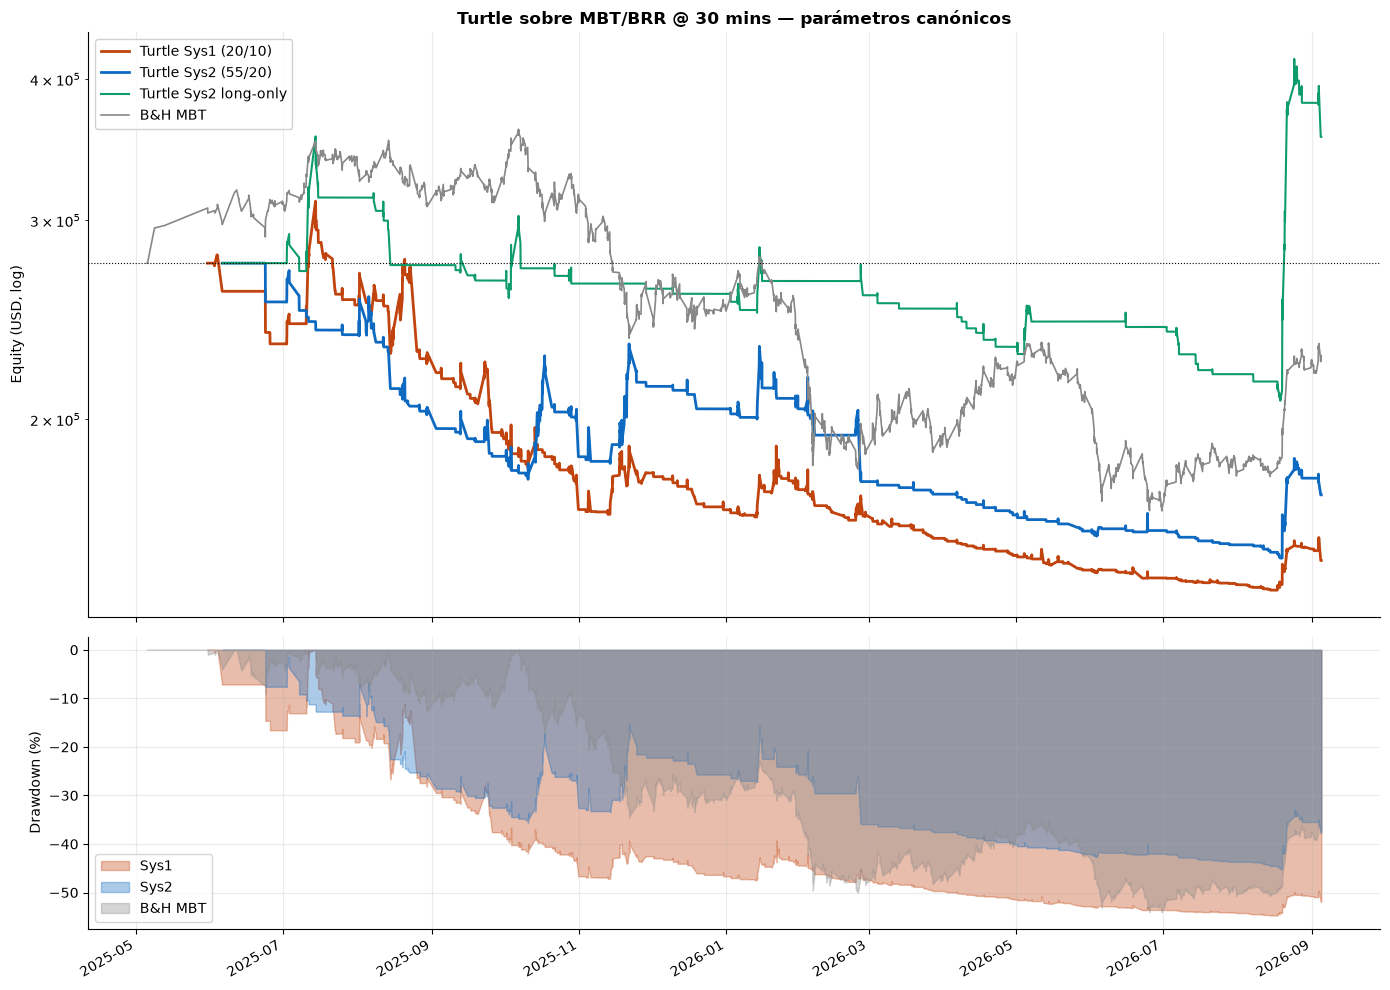

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1], sharex=True)

for ec, lab, c, lw in [
        (ec_s1,   f"Turtle Sys1 ({SYS1['entry']}/{SYS1['exit']})", "#c1440e", 2),
        (ec_s2,   f"Turtle Sys2 ({SYS2['entry']}/{SYS2['exit']})", "#0e6ac1", 2),
        (ec_s2lo, "Turtle Sys2 long-only", "#0e9c6a", 1.5),
        (bh,      f"B&H {_bh_sym}", "#888", 1.2)]:
    if len(ec):
        ax[0].plot(ec.index, ec.values, label=lab, color=c, lw=lw)

ax[0].axhline(EQUITY_0, color="k", ls=":", lw=0.8)
if min([ec.min() for ec in (ec_s1, ec_s2, ec_s2lo, bh) if len(ec)] or [1]) > 0:
    ax[0].set_yscale("log")
ax[0].set_ylabel("Equity (USD, log)")
ax[0].set_title(f"Turtle sobre {'/'.join(RAW)} @ {BAR_SIZE} — parámetros canónicos",
                fontweight="bold")
ax[0].legend(loc="upper left", framealpha=0.9)

for ec, lab, c in [(ec_s1, "Sys1", "#c1440e"), (ec_s2, "Sys2", "#0e6ac1"),
                   (bh, f"B&H {_bh_sym}", "#888")]:
    if len(ec):
        ax[1].fill_between(ec.index, (ec/ec.cummax()-1)*100, 0, alpha=0.35, color=c, label=lab)
ax[1].set_ylabel("Drawdown (%)"); ax[1].legend(loc="lower left")
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

## 7. Walk-Forward Optimization

**Diseño:** ventanas rodantes ancladas al **índice de barras**, no al calendario. Es el cambio
necesario para que el mismo código sirva a `1 secs` y a `1 day`: "365 días" no significa nada
cuando la barra es un segundo, mientras que "un año de barras" sí — y sale de `BARS_PER_YEAR`,
medido sobre los datos reales en §3.

- **In-sample (IS):** `IS_BARS` → se optimiza la rejilla
- **Out-of-sample (OOS):** `OOS_BARS` → se aplican los parámetros ganadores, sin tocar nada
- **Paso:** `OOS_BARS` (las ventanas OOS no se solapan → track record OOS concatenable)

**Selección:** Sharpe IS penalizado por drawdown, no Sharpe puro. Optimizar Sharpe a secas
selecciona sistemáticamente el parámetro más apalancado de la rejilla.

⚠️ El número de folds depende de la muestra, y con un solo subyacente cada fold OOS contiene
**muy pocos trades** — un sistema que vive de capturar dos o tres tendencias grandes al año no
produce una muestra estadística en 90 días. Trátalo como diagnóstico cualitativo. Si `n_folds`
sale por debajo de 8, el t-test de abajo no tiene potencia para detectar nada y el propio
notebook lo dice.

In [45]:
# Ventanas en BARRAS, derivadas de la granularidad (§3). Con muestras cortas se
# recortan proporcionalmente para no quedarse con cero folds.
_n_bars = len(next(iter(DATA_S2.values())))
IS_BARS  = int(min(BARS_PER_YEAR,      _n_bars * 0.40))
OOS_BARS = int(min(BARS_PER_YEAR/4,    _n_bars * 0.10))
IS_BARS, OOS_BARS = max(IS_BARS, ATR_PERIOD*4), max(OOS_BARS, ATR_PERIOD*2)

print(f"  Barras disponibles : {_n_bars:,}")
print(f"  IS  : {IS_BARS:,} barras (~{IS_BARS/BARS_PER_YEAR:.2f} años)")
print(f"  OOS : {OOS_BARS:,} barras (~{OOS_BARS/BARS_PER_YEAR*12:.1f} meses)")
print(f"  Folds estimados : {max(0, (_n_bars - IS_BARS)//OOS_BARS)}")

# Rejilla deliberadamente pequeña. Rejillas grandes sobre muestras cortas =
# overfitting garantizado (skill /backtester).
GRID = [
    {"entry": e, "exit": x, "stop_n": sn, "risk": rk}
    for e, x in [(20, 10), (55, 20), (100, 20)]
    for sn in [1.0, 2.0]
    for rk in [0.005, 0.01]
]
print(f"\n  Combinaciones: {len(GRID)}")

# Pre-computar datasets por (entry, exit). (55,20) siempre presente: es el baseline
# canónico contra el que se compara cada fold.
_pairs = sorted({(g["entry"], g["exit"]) for g in GRID} | {(55, 20)})
PREP = {p: {s: prepare(d, *p) for s, d in RAW.items()} for p in _pairs}
print(f"  Datasets precomputados: {len(PREP)}")

  Barras disponibles : 4,132
  IS  : 1,652 barras (~0.53 años)
  OOS : 413 barras (~1.6 meses)
  Folds estimados : 6

  Combinaciones: 12
  Datasets precomputados: 3


*MAE* is defined as a percentile of the winners' MAE distribution — a statistic of realized trade outcomes, i.e. it conditions on the label. Under checklist.md:25-26 and lopez_de_prado.md:43-66, computing it on the full sample is a full-sample normalization and the winner/loser split is itself outcome information; it must be estimated inside each training fold, with the t1 used for purging being the trade close under the fold-local threshold. Additionally, changing the stop changes t1, which changes the purge sets — so the fold construction is not fixed across candidate thresholds. Neither lopez_de_prado.md nor MAE.md addresses this circularity, and no script handles it.

In [46]:
def score_is(ec, penalty=0.5):
    """Sharpe IS penalizado por drawdown. Evita elegir el parámetro más apalancado."""
    m = metrics(ec)
    if not m or m["Volatilidad"] == 0:
        return -np.inf
    return m["Sharpe"] - penalty*abs(m["Max DD"])


def walk_forward(is_bars=None, oos_bars=None, grid=None, verbose=True):
    """WFO rodante por POSICIÓN de barra. Devuelve (df_folds, equity_oos_concatenada)."""
    is_bars, oos_bars, grid = is_bars or IS_BARS, oos_bars or OOS_BARS, grid or GRID
    # Índice maestro: unión de barras de todos los símbolos, ordenada. Con un solo
    # subyacente es el índice del símbolo; con MBT+BRR se alinean los dos calendarios.
    idx = pd.DatetimeIndex(sorted(set().union(*[set(d.index) for d in RAW.values()])))

    folds, oos_rets, i = [], [], is_bars
    while i + oos_bars <= len(idx):
        is_a, is_b   = idx[i-is_bars], idx[i-1]
        oos_a, oos_b = idx[i], idx[min(i+oos_bars, len(idx)-1)]

        best, best_sc = None, -np.inf
        for g in grid:
            ec, _ = run_turtle(PREP[(g["entry"], g["exit"])], g["entry"], g["exit"],
                               stop_n=g["stop_n"], risk=g["risk"], start=is_a, end=is_b)
            sc = score_is(ec)
            if sc > best_sc:
                best_sc, best = sc, g

        ec_o, tr_o = run_turtle(PREP[(best["entry"], best["exit"])], best["entry"], best["exit"],
                                stop_n=best["stop_n"], risk=best["risk"], start=oos_a, end=oos_b)
        ec_b, _ = run_turtle(PREP[(55, 20)], 55, 20, start=oos_a, end=oos_b)

        r_oos  = ec_o.iloc[-1]/ec_o.iloc[0]-1 if len(ec_o) > 1 else 0.0
        r_base = ec_b.iloc[-1]/ec_b.iloc[0]-1 if len(ec_b) > 1 else 0.0

        folds.append({"fold": len(folds)+1, "oos_ini": oos_a, "oos_fin": oos_b,
                      **{f"p_{k}": v for k, v in best.items()},
                      "IS_score": round(best_sc, 3), "OOS_ret": r_oos,
                      "BASE_ret": r_base, "trades": len(tr_o)})
        if len(ec_o) > 1:
            oos_rets.append(ec_o.pct_change().dropna())
        if verbose:
            print(f"  Fold {len(folds):2d} | {oos_a:%Y-%m-%d %H:%M} → {oos_b:%Y-%m-%d %H:%M} | "
                  f"e{best['entry']}/x{best['exit']} sn{best['stop_n']} r{best['risk']} | "
                  f"OOS {r_oos:+7.2%} vs base {r_base:+7.2%} ({len(tr_o)} trades)")
        i += oos_bars

    df = pd.DataFrame(folds)
    eq = (EQUITY_0*(1+pd.concat(oos_rets).sort_index()).cumprod()) if oos_rets else pd.Series(dtype=float)
    return df, eq

print("Ejecutando walk-forward (puede tardar varios minutos)...\n")
FOLDS, EC_WFO = walk_forward()

Ejecutando walk-forward (puede tardar varios minutos)...

  Fold  1 | 2025-12-03 17:30 → 2026-01-23 15:30 | e55/x20 sn2.0 r0.01 | OOS  -2.23% vs base  -3.29% (5 trades)
  Fold  2 | 2026-01-23 15:30 → 2026-03-12 20:00 | e55/x20 sn1.0 r0.01 | OOS -23.66% vs base -23.66% (10 trades)
  Fold  3 | 2026-03-12 20:00 → 2026-04-24 16:30 | e55/x20 sn2.0 r0.01 | OOS -35.17% vs base -13.23% (11 trades)
  Fold  4 | 2026-04-24 16:30 → 2026-06-05 20:00 | e100/x20 sn2.0 r0.005 | OOS +27.30% vs base +17.22% (5 trades)
  Fold  5 | 2026-06-05 20:00 → 2026-07-21 16:30 | e100/x20 sn2.0 r0.005 | OOS -12.49% vs base -14.36% (5 trades)
  Fold  6 | 2026-07-21 16:30 → 2026-08-31 20:00 | e100/x20 sn2.0 r0.005 | OOS +77.27% vs base +24.51% (5 trades)


In [47]:
if not len(FOLDS):
    print("Sin folds: la muestra no da para IS+OOS. Baja BAR_SIZE o sube LOOKBACK_DAYS.")
else:
    display(FOLDS.style.format({"OOS_ret": "{:+.2%}", "BASE_ret": "{:+.2%}",
                                "IS_score": "{:.3f}"})
            .background_gradient(subset=["OOS_ret"], cmap="RdYlGn", vmin=-0.3, vmax=0.3))

    wins = int((FOLDS.OOS_ret > FOLDS.BASE_ret).sum())
    print(f"\n{'='*70}")
    print(f"  WFO gana al baseline canónico en {wins}/{len(FOLDS)} folds ({wins/len(FOLDS):.0%})")
    print(f"  Retorno OOS medio  — WFO: {FOLDS.OOS_ret.mean():+.2%} | "
          f"baseline: {FOLDS.BASE_ret.mean():+.2%}")
    print(f"  Folds OOS positivos— WFO: {(FOLDS.OOS_ret>0).mean():.0%} | "
          f"baseline: {(FOLDS.BASE_ret>0).mean():.0%}")
    print(f"  Trades OOS totales : {FOLDS.trades.sum()} "
          f"(mediana {FOLDS.trades.median():.0f} por fold)")
    print(f"{'='*70}")

    from scipy import stats
    d = FOLDS.OOS_ret - FOLDS.BASE_ret
    t, p = stats.ttest_1samp(d, 0) if len(d) > 1 else (np.nan, 1.0)
    print(f"\n  t-test (WFO − baseline): t={t:.3f}, p={p:.3f}, n={len(d)}")
    if len(d) < 8:
        print(f"  ⚠️  n={len(d)} folds: el test NO tiene potencia. No concluyas nada de p.")
    print(f"  → {'Diferencia NO significativa: la optimización es ruido.' if p > 0.05 else 'Diferencia significativa (ojo: n pequeño).'}")

    print(f"\n  Estabilidad de parámetros elegidos:")
    for c in ["p_entry", "p_exit", "p_stop_n", "p_risk"]:
        vc = FOLDS[c].value_counts()
        print(f"    {c:<10}: {dict(vc)}  → moda {vc.iloc[0]/len(FOLDS):.0%} de los folds")

,fold,oos_ini,oos_fin,p_entry,p_exit,p_stop_n,p_risk,IS_score,OOS_ret,BASE_ret,trades
0,1,2025-12-03 17:30:00,2026-01-23 15:30:00,55,20,2.000000,0.010000,-0.066,-2.23%,-3.29%,5
1,2,2026-01-23 15:30:00,2026-03-12 20:00:00,55,20,1.000000,0.010000,-0.227,-23.66%,-23.66%,10
2,3,2026-03-12 20:00:00,2026-04-24 16:30:00,55,20,2.000000,0.010000,2.640,-35.17%,-13.23%,11
3,4,2026-04-24 16:30:00,2026-06-05 20:00:00,100,20,2.000000,0.005000,0.599,+27.30%,+17.22%,5
4,5,2026-06-05 20:00:00,2026-07-21 16:30:00,100,20,2.000000,0.005000,1.721,-12.49%,-14.36%,5
5,6,2026-07-21 16:30:00,2026-08-31 20:00:00,100,20,2.000000,0.005000,0.930,+77.27%,+24.51%,5



  WFO gana al baseline canónico en 4/6 folds (67%)
  Retorno OOS medio  — WFO: +5.17% | baseline: -2.13%
  Folds OOS positivos— WFO: 33% | baseline: 33%
  Trades OOS totales : 41 (mediana 5 por fold)

  t-test (WFO − baseline): t=0.724, p=0.501, n=6
  ⚠️  n=6 folds: el test NO tiene potencia. No concluyas nada de p.
  → Diferencia NO significativa: la optimización es ruido.

  Estabilidad de parámetros elegidos:
    p_entry   : {55: np.int64(3), 100: np.int64(3)}  → moda 50% de los folds
    p_exit    : {20: np.int64(6)}  → moda 100% de los folds
    p_stop_n  : {2.0: np.int64(5), 1.0: np.int64(1)}  → moda 83% de los folds
    p_risk    : {0.01: np.int64(3), 0.005: np.int64(3)}  → moda 50% de los folds


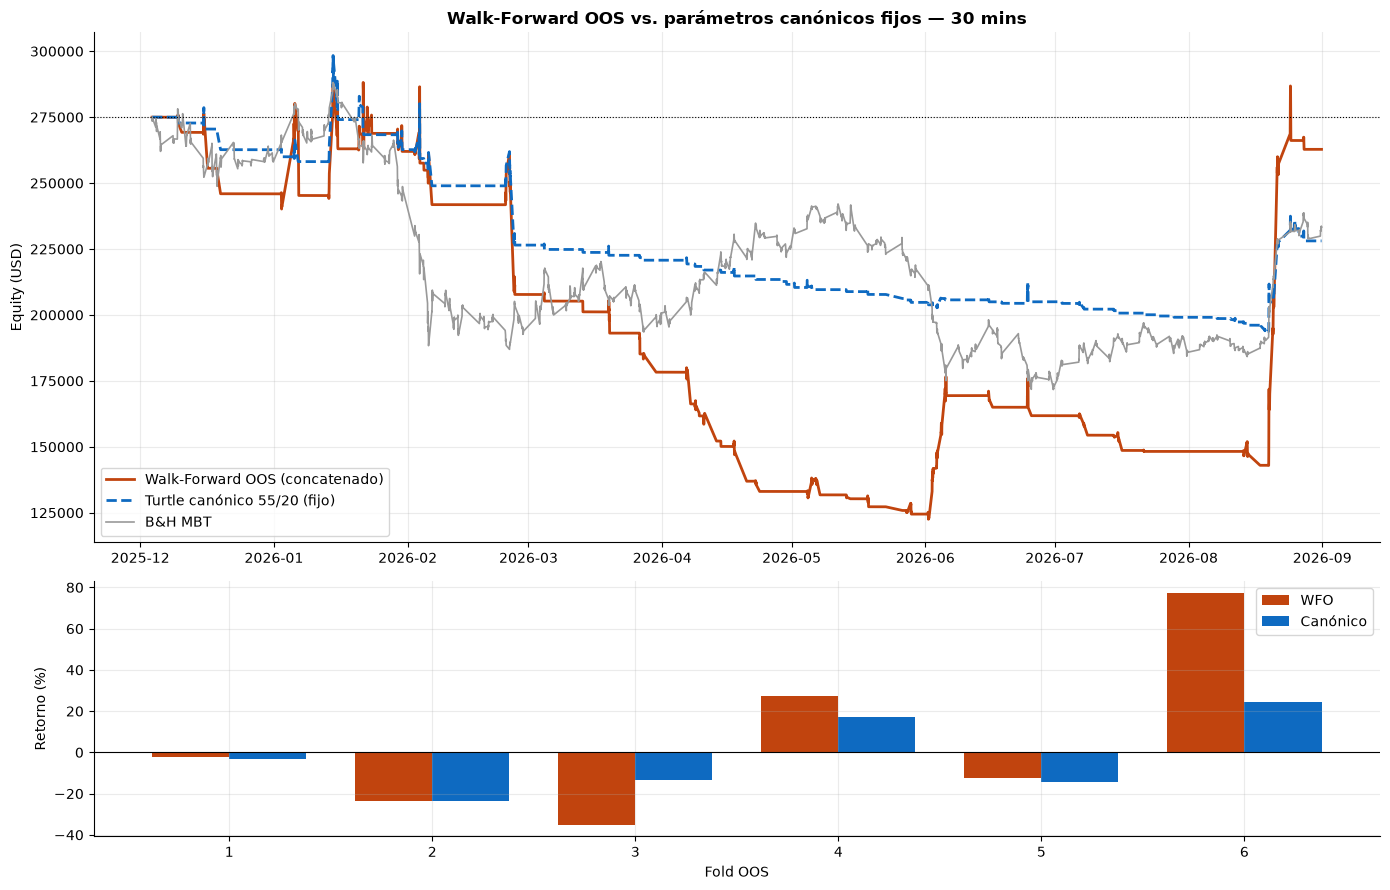


  WALK-FORWARD OUT-OF-SAMPLE
  Retorno total         :     -4.44%
  CAGR                  :     -5.93%
  Volatilidad           :     58.63%
  Sharpe                :      -0.10
  Sortino               :      -0.07
  Max DD                :    -57.48%
  Calmar                :      -0.10
  Barras en DD>20%      :       1706
  Años                  :       0.74


In [48]:
if len(FOLDS) and len(EC_WFO):
    fig, ax = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[2, 1])

    ax[0].plot(EC_WFO.index, EC_WFO.values, label="Walk-Forward OOS (concatenado)",
               color="#c1440e", lw=2)
    ec_b_full, _ = run_turtle(PREP[(55, 20)], 55, 20)
    _al = ec_b_full.reindex(EC_WFO.index).ffill()
    ax[0].plot(_al.index, (_al/_al.iloc[0]*EQUITY_0).values,
               label="Turtle canónico 55/20 (fijo)", color="#0e6ac1", lw=2, ls="--")
    _bt = bh.reindex(EC_WFO.index).ffill()
    ax[0].plot(_bt.index, (_bt/_bt.iloc[0]*EQUITY_0).values,
               label=f"B&H {_bh_sym}", color="#999", lw=1.2)
    ax[0].axhline(EQUITY_0, color="k", ls=":", lw=0.8)
    ax[0].set_ylabel("Equity (USD)")
    ax[0].set_title(f"Walk-Forward OOS vs. parámetros canónicos fijos — {BAR_SIZE}",
                    fontweight="bold")
    ax[0].legend()

    w = 0.38; x = np.arange(len(FOLDS))
    ax[1].bar(x-w/2, FOLDS.OOS_ret*100, w, label="WFO", color="#c1440e")
    ax[1].bar(x+w/2, FOLDS.BASE_ret*100, w, label="Canónico", color="#0e6ac1")
    ax[1].axhline(0, color="k", lw=0.8)
    ax[1].set_xticks(x); ax[1].set_xticklabels(FOLDS.fold)
    ax[1].set_xlabel("Fold OOS"); ax[1].set_ylabel("Retorno (%)"); ax[1].legend()
    plt.tight_layout(); plt.show()

    show(metrics(EC_WFO), "WALK-FORWARD OUT-OF-SAMPLE")

## 8. Cuantificación de sesgos

Aquí el backtest se gana o pierde la credibilidad. El sesgo 1 sustituye al *survivorship* del
notebook diversificado: con un solo subyacente que sigue vivo no hay supervivencia que medir,
pero sí un problema equivalente de construcción de la serie — **el roll**.

In [49]:
# ── SESGO 1: ROLL / EMPALME DE CONTRATOS ──
# La serie se cose sin ajustar: en cada roll hay un salto de precio entre el
# contrato que se abandona y el que se toma. Ese salto entra en la curva como un
# retorno que NADIE cobró — no es beneficio ni pérdida, es un artefacto del
# empalme. Con DATA_SOURCE="chain" las fechas de roll son conocidas (§3), así que
# se mide en el punto exacto en vez de adivinarlo con un percentil.
print("="*74); print("  SESGO 1 — ROLL / EMPALME DE CONTRATOS"); print("="*74)

ROLL_IMPACT = {}
for s, d in RAW.items():
    r = ROLLS.get(s, pd.DataFrame())
    ret = d["close"].pct_change(fill_method=None)

    if len(r) > 1:
        # Salto medido EN el empalme: último cierre del contrato saliente contra
        # el primer cierre del entrante.
        saltos = []
        for i in range(1, len(r)):
            t0, t1 = pd.Timestamp(r.hasta.iloc[i-1]), pd.Timestamp(r.desde.iloc[i])
            prev_px = float(r.ultimo_close.iloc[i-1])
            post = d.loc[d.index >= t1, "close"]
            if not len(post) or prev_px <= 0:
                continue
            saltos.append({"de": r.contrato.iloc[i-1], "a": r.contrato.iloc[i],
                           "fecha": t1, "close_saliente": prev_px,
                           "close_entrante": float(post.iloc[0]),
                           "salto": float(post.iloc[0])/prev_px - 1})
        sdf = pd.DataFrame(saltos)
        if len(sdf):
            anios = max(_span_days/365.25, 1e-9)
            impacto = sdf.salto.sum()
            ROLL_IMPACT[s] = impacto/anios
            print(f"\n  {s}: {len(sdf)} rolls en {anios:.2f} años")
            print(f"     Salto medio        : {sdf.salto.mean():+.3%}")
            print(f"     Salto absoluto máx.: {sdf.salto.abs().max():.3%}")
            print(f"     Suma de saltos     : {impacto:+.2%}  →  "
                  f"{impacto/anios:+.2%}/año de retorno que NO es del mercado")
            display(sdf.style.format({"salto": "{:+.3%}", "close_saliente": "{:,.2f}",
                                      "close_entrante": "{:,.2f}", "fecha": "{:%Y-%m-%d %H:%M}"})
                    .background_gradient(subset=["salto"], cmap="RdYlGn"))
            _cagr_s2 = metrics(ec_s2).get("CAGR", float("nan")) if len(ec_s2) else float("nan")
            print(f"     ⚠ Compáralo con el CAGR del Sistema 2 ({_cagr_s2:+.2%}): si el")
            print( "       impacto anual del roll es del mismo orden, el resultado del")
            print( "       backtest está dominado por el empalme, no por la estrategia.")
    else:
        # Sin tabla de rolls (DATA_SOURCE="cont"): IB no dice dónde empalmó, así
        # que solo queda el proxy estadístico — saltos anómalos barra a barra.
        gap = (d["open"] - d["close"].shift(1)).abs() / d["close"].shift(1)
        thr = max(gap.quantile(0.999), 0.005)
        big = gap[gap > thr].dropna()
        ROLL_IMPACT[s] = float(big.sum()) / max(_span_days/365.25, 1e-9)
        print(f"\n  {s} (fuente 'cont' — IB no expone las fechas de roll):")
        print(f"     {len(big)} saltos barra-a-barra por encima de {thr:.2%}")
        if len(big):
            print(f"     Salto medio {big.mean():.2%} | máximo {big.max():.2%} | "
                  f"suma {big.sum():.2%} ≈ {ROLL_IMPACT[s]:+.2%}/año")
        print( "     Es un PROXY, no una medida: cambia a DATA_SOURCE='chain' para")
        print( "     medir el empalme en el punto exacto.")

  SESGO 1 — ROLL / EMPALME DE CONTRATOS

  MBT: 12 rolls en 1.33 años
     Salto medio        : +1.231%
     Salto absoluto máx.: 5.031%
     Suma de saltos     : +14.77%  →  +11.07%/año de retorno que NO es del mercado


,de,a,fecha,close_saliente,close_entrante,salto
0,MBTU5,MBTV5,2025-09-24 13:30,"112,050.00","113,755.00",+1.522%
1,MBTV5,MBTX5,2025-10-29 13:30,"112,915.00","113,450.00",+0.474%
2,MBTX5,MBTZ5,2025-11-26 14:30,"87,030.00","87,180.00",+0.172%
3,MBTZ5,MBTF6,2025-12-24 14:30,"87,655.00","87,350.00",-0.348%
4,MBTF6,MBTG6,2026-01-28 14:30,"89,100.00","89,915.00",+0.915%
5,MBTG6,MBTH6,2026-02-25 14:30,"64,105.00","67,330.00",+5.031%
6,MBTH6,MBTJ6,2026-03-25 13:30,"70,115.00","71,835.00",+2.453%
7,MBTJ6,MBTK6,2026-04-22 13:30,"75,735.00","79,365.00",+4.793%
8,MBTK6,MBTM6,2026-05-27 13:30,"75,960.00","75,175.00",-1.033%
9,MBTM6,MBTN6,2026-06-24 13:30,"62,385.00","61,495.00",-1.427%


     ⚠ Compáralo con el CAGR del Sistema 2 (-31.50%): si el
       impacto anual del roll es del mismo orden, el resultado del
       backtest está dominado por el empalme, no por la estrategia.

  BRR: 12 rolls en 1.33 años
     Salto medio        : +1.185%
     Salto absoluto máx.: 5.021%
     Suma de saltos     : +14.22%  →  +10.66%/año de retorno que NO es del mercado


,de,a,fecha,close_saliente,close_entrante,salto
0,BTCU5,BTCV5,2025-09-24 13:30,"111,970.00","113,695.00",+1.541%
1,BTCV5,BTCX5,2025-10-29 13:30,"112,975.00","113,460.00",+0.429%
2,BTCX5,BTCZ5,2025-11-26 14:30,"87,200.00","87,250.00",+0.057%
3,BTCZ5,BTCF6,2025-12-24 14:30,"87,645.00","87,280.00",-0.416%
4,BTCF6,BTCG6,2026-01-28 14:30,"89,375.00","89,935.00",+0.627%
5,BTCG6,BTCH6,2026-02-25 14:30,"64,330.00","67,305.00",+4.625%
6,BTCH6,BTCJ6,2026-03-25 13:30,"69,400.00","71,965.00",+3.696%
7,BTCJ6,BTCK6,2026-04-22 13:30,"75,580.00","79,375.00",+5.021%
8,BTCK6,BTCM6,2026-05-27 13:30,"75,985.00","75,170.00",-1.073%
9,BTCM6,BTCN6,2026-06-24 13:30,"62,430.00","61,475.00",-1.530%


     ⚠ Compáralo con el CAGR del Sistema 2 (-31.50%): si el
       impacto anual del roll es del mismo orden, el resultado del
       backtest está dominado por el empalme, no por la estrategia.


In [50]:
# Verdad de campo: la serie que se ha backtesteado contra el contrato que se
# operaría HOY. Si divergen, el backtest opera precios que el contrato real no tuvo.
if IBS is None:
    print("  Sin sesión IBKR: no se puede contrastar contra el contrato vigente.")
else:
    for s in RAW:
        try:
            contract, detail, expiry = front_month(
                IBS, s, UNIVERSE[s]["exchange"], UNIVERSE[s]["currency"])
            dur, _ = ib_chunk(BAR_SECONDS)
            bars = IBS.reqHistoricalData(contract, endDateTime="", durationStr=dur,
                                         barSizeSetting=BAR_SIZE, whatToShow=WHAT_TO_SHOW,
                                         useRTH=USE_RTH, formatDate=2, timeout=60)
            real = _bars_to_df(bars)
            common = RAW[s].index.intersection(real.index)
            if len(common) < 10:
                print(f"  {s}: solapamiento insuficiente ({len(common)} barras)"); continue
            rel = (RAW[s].loc[common, "close"] - real.loc[common, "close"]) / real.loc[common, "close"]
            print(f"\n  {s} — serie usada vs. {contract.localSymbol} (exp. {expiry}), "
                  f"{len(common)} barras solapadas")
            print(f"     Diferencia media : {rel.mean():+.4%}")
            print(f"     Diferencia máx.  : {rel.abs().max():.4%}")
            print(f"     {'✓ La serie sigue al contrato vigente en esta ventana.' if rel.abs().max() < 0.002 else '⚠ Divergen: el backtest opera precios que el contrato real no tuvo.'}")
        except Exception as e:
            print(f"  {s}: no se pudo contrastar ({e})")

  Sin sesión IBKR: no se puede contrastar contra el contrato vigente.


  SESGO 2 — CONCENTRACIÓN DE P&L

  Top  1 trades = -27.7% del P&L total

  Top  3 trades = -72.3% del P&L total

  Top  5 trades = -93.2% del P&L total

  Top 10 trades = -105.8% del P&L total

  P&L total: $-101,330 en 104 trades
  Sin el mejor trade: $-129,375  (-47.0% sobre capital inicial)

  Mejores 5 trades:


,symbol,side,opened,closed,units,contracts,pnl,horas
0,MBT,-1,2025-10-10 17:00:00,2025-10-20 13:30:00,4,40,28045.20,236.5
1,MBT,-1,2025-11-17 15:00:00,2025-11-24 16:30:00,4,40,25755.20,169.5
2,MBT,1,2026-08-20 14:00:00,2026-08-26 14:30:00,4,32,19437.66,144.5
3,MBT,1,2026-01-13 16:00:00,2026-01-15 19:30:00,4,80,12450.40,51.5
4,MBT,1,2026-08-19 14:00:00,2026-08-19 17:00:00,4,61,8706.18,3.0



  Peores 5 trades:


,symbol,side,opened,closed,units,contracts,pnl,horas
99,MBT,-1,2025-08-29 14:00:00,2025-09-02 13:30:00,3,57,-7046.34,95.5
100,MBT,-1,2025-10-30 14:00:00,2025-10-31 13:30:00,4,56,-15574.72,23.5
101,MBT,1,2025-08-13 19:30:00,2025-08-14 13:30:00,1,35,-16594.20,18.0
102,MBT,-1,2026-02-23 16:30:00,2026-02-25 14:30:00,4,80,-16797.60,46.0
103,MBT,-1,2025-06-23 16:30:00,2025-06-23 17:30:00,1,72,-20852.64,1.0


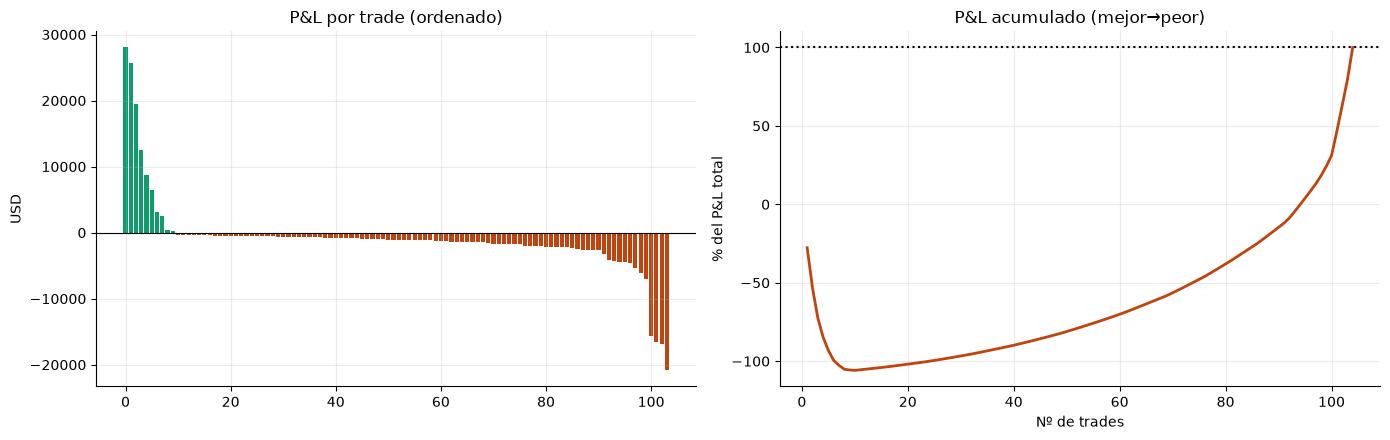

In [51]:
# ── SESGO 2: CONCENTRACIÓN DE P&L ──
# Turtle vive de pocas tendencias enormes. Si 3 trades hacen todo el resultado,
# el track record es una muestra de tamaño 3, no de tamaño N. Con UN subyacente
# esto es mucho peor que en el notebook diversificado: no hay 50 mercados donde
# repartir la suerte.
print("="*74); print("  SESGO 2 — CONCENTRACIÓN DE P&L"); print("="*74)

if not len(tr_s2):
    print("\n  Sin trades cerrados: nada que concentrar (revisa §6, ejecutabilidad).")
    tr, tot = tr_s2, 0.0
else:
    tr = tr_s2.sort_values("pnl", ascending=False).reset_index(drop=True)
    tot = tr.pnl.sum()
    for k in [1, 3, 5, 10]:
        if len(tr) >= k and tot:
            print(f"\n  Top {k:>2} trades = {tr.pnl.head(k).sum()/tot:>6.1%} del P&L total")
    print(f"\n  P&L total: ${tot:,.0f} en {len(tr)} trades")
    if tot:
        print(f"  Sin el mejor trade: ${tot - tr.pnl.iloc[0]:,.0f}  "
              f"({(tot-tr.pnl.iloc[0])/EQUITY_0:+.1%} sobre capital inicial)")

    print(f"\n  Mejores 5 trades:"); display(
        tr.head(5)[["symbol","side","opened","closed","units","contracts","pnl","horas"]])
    print(f"\n  Peores 5 trades:"); display(
        tr.tail(5)[["symbol","side","opened","closed","units","contracts","pnl","horas"]])

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    ax[0].bar(range(len(tr)), tr.pnl.values,
              color=np.where(tr.pnl > 0, "#0e9c6a", "#c1440e"))
    ax[0].set_title("P&L por trade (ordenado)"); ax[0].set_ylabel("USD")
    ax[0].axhline(0, color="k", lw=.8)
    if tot:
        ax[1].plot(np.arange(1, len(tr)+1), tr.pnl.cumsum().values/tot*100,
                   color="#c1440e", lw=2)
        ax[1].axhline(100, ls=":", color="k")
    ax[1].set_title("P&L acumulado (mejor→peor)")
    ax[1].set_xlabel("Nº de trades"); ax[1].set_ylabel("% del P&L total")
    plt.tight_layout(); plt.show()

In [52]:
# ── SESGO 3: DIVERSIFICACIÓN — cuántas apuestas independientes hay realmente ──
# En el notebook diversificado esto era una matriz de correlación de 50 activos.
# Aquí el resultado se conoce de antemano y por eso mismo hay que escribirlo:
# MBT y BRR son el MISMO subyacente. n_eff ≈ 1.
print("="*74); print("  SESGO 3 — DIVERSIFICACIÓN INEXISTENTE"); print("="*74)

if len(RAW) < 2:
    n_eff = 1.0
    print(f"\n  Un solo instrumento ({list(RAW)[0]}) → n_eff = 1.00 por construcción.")
else:
    rets = pd.DataFrame({s: d["close"].pct_change(fill_method=None) for s, d in RAW.items()})
    rets = rets.replace([np.inf, -np.inf], np.nan).dropna()
    corr = rets.corr()
    display(corr.style.background_gradient(cmap="RdYlGn_r", vmin=-1, vmax=1))
    ev = np.linalg.eigvalsh((corr.values + corr.values.T)/2)[::-1]
    ev = ev[ev > 1e-12]
    n_eff = (ev.sum()**2)/(ev**2).sum()
    print(f"\n  Correlación MBT–BRR : {corr.iloc[0,1]:.4f}")
    print(f"  n_eff               : {n_eff:.2f} sobre {len(corr)} instrumentos")

print(f"\n  ➜ Nº EFECTIVO de apuestas independientes: {n_eff:.2f}")
print( "     El sistema Turtle original operaba ~20 futuros genuinamente descorrelacionados.")
print(f"     Con {n_eff:.0f}, la ley de los grandes números que hacía viable un win-rate del")
print( "     35% sencillamente no opera. Un drawdown del 50%+ no es cola: es el escenario")
print( "     central. Éste es el hallazgo más importante de este notebook.")

  SESGO 3 — DIVERSIFICACIÓN INEXISTENTE


,MBT,BRR
MBT,1.000000,0.982907
BRR,0.982907,1.000000



  Correlación MBT–BRR : 0.9829
  n_eff               : 1.02 sobre 2 instrumentos

  ➜ Nº EFECTIVO de apuestas independientes: 1.02
     El sistema Turtle original operaba ~20 futuros genuinamente descorrelacionados.
     Con 1, la ley de los grandes números que hacía viable un win-rate del
     35% sencillamente no opera. Un drawdown del 50%+ no es cola: es el escenario
     central. Éste es el hallazgo más importante de este notebook.


In [53]:
# ── SESGO 4: SENSIBILIDAD A COSTES ──
# Si el edge muere al doblar el slippage, no era un edge. En un futuro el coste
# NO es proporcional al nocional: es fijo por contrato, así que su peso relativo
# crece cuando el sizing se hace pequeño y cuando la granularidad se hace fina.
print("="*74); print("  SESGO 4 — SENSIBILIDAD A COSTES"); print("="*74)

def _scaled(mult_comm, slip_ticks):
    return {s: {"comm": COSTS[s]["comm"]*mult_comm, "slip_ticks": slip_ticks}
            for s in COSTS}

rows = []
for lbl, mc, st in [("Sin costes", 0.0, 0.0), ("Optimista", 0.5, 0.0),
                    ("Base", 1.0, COSTS[next(iter(COSTS))]["slip_ticks"]),
                    ("Pesimista", 1.5, 2.0), ("Estrés", 2.0, 4.0)]:
    ec_c, tr_c = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], costs=_scaled(mc, st))
    m = metrics(ec_c, tr_c)
    rows.append({"Escenario": lbl, "Comisión ×": mc, "Slippage (ticks)": st,
                 "CAGR": m.get("CAGR", np.nan), "Sharpe": m.get("Sharpe", np.nan),
                 "MaxDD": m.get("Max DD", np.nan), "Trades": m.get("Trades", 0)})

cost_df = pd.DataFrame(rows)
display(cost_df.style.format({"CAGR": "{:+.2%}", "MaxDD": "{:.1%}", "Sharpe": "{:.2f}"})
        .background_gradient(subset=["CAGR"], cmap="RdYlGn"))

deg = cost_df.CAGR.iloc[0] - cost_df.CAGR.iloc[2]
print(f"\n  Coste de fricción: {deg:.2%} de CAGR (sin costes → base)")
print(f"  {'⚠️  El edge NO sobrevive costes realistas.' if cost_df.CAGR.iloc[3] <= 0 else '✓ El edge sobrevive el escenario pesimista.'}")

# Demostración de por qué FUNDING = 0 en futuros: cobrarlo es inventar un coste
# que escala con el nocional mientras el sizing escala con el riesgo.
ec_f, tr_f = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], funding=0.0001*3)
m_f = metrics(ec_f, tr_f)
print(f"\n  Control — si se cobrara funding de perpetuo (11%/año) a un futuro:")
print(f"     CAGR {cost_df.CAGR.iloc[2]:+.2%} → {m_f.get('CAGR', float('nan')):+.2%}   "
      f"(coste inventado; los futuros no lo pagan)")

  SESGO 4 — SENSIBILIDAD A COSTES


,Escenario,Comisión ×,Slippage (ticks),CAGR,Sharpe,MaxDD,Trades
0,Sin costes,0.000000,0.000000,-28.44%,-0.78,-43.9%,102
1,Optimista,0.500000,0.000000,-29.22%,-0.81,-44.3%,102
2,Base,1.000000,1.000000,-31.50%,-0.93,-45.2%,104
3,Pesimista,1.500000,2.000000,-32.18%,-0.97,-45.4%,104
4,Estrés,2.000000,4.000000,-32.96%,-1.00,-45.9%,105



  Coste de fricción: 3.05% de CAGR (sin costes → base)
  ⚠️  El edge NO sobrevive costes realistas.

  Control — si se cobrara funding de perpetuo (11%/año) a un futuro:
     CAGR -31.50% → -38.95%   (coste inventado; los futuros no lo pagan)


## 8.5 MAE / MFE — ganadores frente a perdedores

La sección que pide la Parte B del enunciado, y la que decide si toda la capa de triple barrera
se gana el sitio.

**El orden de lectura importa.** Primero se mira la curva `P(ganador | MAE ≥ x)`. Si es plana, la
excursión adversa no dice nada sobre el desenlace, cortar por ella solo añade coste, y ningún
Sharpe posterior salva el argumento. Solo si la curva cae con claridad tiene sentido buscar un
umbral.

**Población de calibración.** Las distribuciones se miden sobre trades cerrados **solo por la
barrera vertical**, sin stop que trunque el camino (`mae_stop_n = inf`). Es deliberado: si se
calibrara sobre la población que el propio stop ha modelado, la MAE estaría acotada por el stop
por construcción y el cuantil saldría sesgado a lo estrecho — se estaría midiendo el stop, no el
mercado. El precio de esta elección es que la población observada no es la que se opera, y sus
ganadores incluyen trades que un stop habría eliminado; el sesgo va hacia umbrales **más
anchos**, que es el lado conservador.

**Por qué el stop de la calibración importa tanto.** Una población observada con un stop muy
apretado está **truncada por su propio stop**: la MAE de los ganadores no puede superar el stop
por construcción, así que el cuantil no tiene sitio donde caer y sale pegado al propio nivel —
se estaría midiendo el stop, no el mercado. Y al revés: sin stop ninguno, la población incluye
trades que en la práctica nunca se habrían mantenido. Por eso se comparan tres regímenes de stop
inicial (**sin stop, 2N y 1N**) y se reporta cómo se mueve MAE\* entre ellos: ese desplazamiento
**es** el sesgo de truncamiento, medido en vez de supuesto.

**Suelo de resolución.** Un umbral por debajo del rango típico de vela no es distinguible dentro
de la propia barra: el backtest estaría inventando un orden de eventos que nunca observó. Ese
suelo se mide y se usa para recortar el cuantil, y para negarse a barrer percentiles que la
granularidad no puede resolver.

In [54]:
# ── Poblaciones de calibración bajo tres regímenes de stop inicial ─────────
# El stop trunca el camino, y por tanto trunca la MAE observable. Comparar los
# tres deja el sesgo a la vista en vez de esconderlo detrás de una sola cifra.
FLOOR_N = float(pd.concat([d["rng_n"] for d in DATA_S2.values()]).median())

def observe(stop_n_calib):
    """Población de observación: sin objetivo y sin canal, solo el stop indicado
    y la barrera vertical. `sizing_equity='fixed'` evita que la curva —que en esta
    corrida no es una estrategia desplegable— realimente el tamaño y vacíe la
    muestra en silencio."""
    _sn = float("inf") if stop_n_calib is None else stop_n_calib
    _stop_n = STOP_N if stop_n_calib is None else stop_n_calib
    return run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"],
                      stop_n=_stop_n, mae_stop_n=_sn, take_n=None,
                      max_hold_bars=MAX_HOLD_BARS, use_donchian_exit=False,
                      require_confirmation=REQUIRE_CONFIRMATION,
                      sizing_equity="fixed", use_dd_rule=False,
                      max_gross_lev=None)[1]

REGIMES, CALIB = {}, []
for lbl, sc in [("sin stop", None), (f"stop {CALIB_STOP_N:.0f}N", CALIB_STOP_N),
                (f"stop {STOP_N:.0f}N", STOP_N)]:
    tr = observe(sc)
    if not len(tr):
        continue
    tr["win"] = tr.pnl > 0
    stop_n_used = STOP_N if sc is None else sc
    star, info = mae_star(tr.mae_n, tr.win, q=0.90, min_winners=30,
                          flat_frac=tr.flat_frac, resolvable_floor=FLOOR_N,
                          fallback=stop_n_used)
    cur = win_prob_curve(tr.mae_n, tr.win, grid=np.arange(0.0, 4.01, 0.25))
    res = cur[cur.x_n >= FLOOR_N]
    REGIMES[lbl] = {"trades": tr, "star": star, "info": info, "curve": cur,
                    "stop_n": stop_n_used}
    CALIB.append({
        "régimen": lbl, "R": f"{stop_n_used:.0f}N", "trades": len(tr),
        "ganadores": int(tr.win.sum()), "tasa_acierto": tr.win.mean(),
        "sobreviven_vertical": (tr.exit_reason == "vertical").mean(),
        "MAE_p50_gan": tr.loc[tr.win, "mae_n"].median(),
        "MAE_p90_gan": tr.loc[tr.win, "mae_n"].quantile(.90),
        "MAE*_N": star, "MAE*_R": star / stop_n_used,
        "lift": res.lift.mean(), "KS": cur.ks.max(),
        "fallback": info["fallback_usado"],
    })

CALIB = pd.DataFrame(CALIB)
print("="*82); print("  POBLACIONES DE CALIBRACIÓN — el stop inicial cambia lo que se puede ver")
print("="*82)
print(f"\n  Suelo de resolución intrabarra: {FLOOR_N:.2f} N "
      f"(rango mediano de vela a {BAR_SIZE})")
display(CALIB.style.format({
    "tasa_acierto": "{:.0%}", "sobreviven_vertical": "{:.0%}",
    "MAE_p50_gan": "{:.2f}", "MAE_p90_gan": "{:.2f}",
    "MAE*_N": "{:.2f}", "MAE*_R": "{:.2f}", "lift": "{:+.3f}", "KS": "{:.2f}"}))

# El régimen de referencia para el resto de la sección.
_KEY = f"stop {CALIB_STOP_N:.0f}N"
TR_OBS = REGIMES[_KEY]["trades"]
MAE_STAR = REGIMES[_KEY]["star"]
MAE_INFO = REGIMES[_KEY]["info"]
CUR = REGIMES[_KEY]["curve"]
W, L = TR_OBS[TR_OBS.win], TR_OBS[~TR_OBS.win]

print(f"\n  Régimen de referencia: {_KEY}  →  MAE* = {MAE_STAR:.2f} N = "
      f"{MAE_STAR/CALIB_STOP_N:.2f} R")
print(f"  E-ratio (MFE/MAE)    : {edge_ratio(TR_OBS.mfe_n, TR_OBS.mae_n):.2f}"
      "   (<1 ⇒ la ENTRADA no tiene ventaja direccional inmediata)")

# El desplazamiento de MAE* entre regímenes ES el sesgo de truncamiento.
if len(CALIB) >= 2:
    _sp = CALIB.set_index("régimen")["MAE*_N"]
    print(f"\n  Sesgo de truncamiento: MAE* va de {_sp.min():.2f}N a {_sp.max():.2f}N "
          f"según el stop con que se observe ({_sp.max()/max(_sp.min(),1e-9):.1f}x).")
    print("  Cuanto más apretado el stop con el que se calibra, más estrecho sale el")
    print("  umbral: el estadístico se muerde la cola. Por eso se calibra con el stop")
    print(f"  ancho ({CALIB_STOP_N:.0f}N) y no con el que se opera.")

  POBLACIONES DE CALIBRACIÓN — el stop inicial cambia lo que se puede ver

  Suelo de resolución intrabarra: 0.76 N (rango mediano de vela a 30 mins)


,régimen,R,trades,ganadores,tasa_acierto,sobreviven_vertical,MAE_p50_gan,MAE_p90_gan,MAE*_N,MAE*_R,lift,KS,fallback
0,sin stop,1N,164,56,34%,100%,0.65,2.07,2.10,2.10,-0.362,0.39,False
1,stop 2N,2N,165,45,27%,55%,0.45,1.35,1.38,0.69,-0.355,0.55,False
2,stop 1N,1N,177,28,16%,15%,0.27,0.67,1.00,1.00,-0.190,0.60,True



  Régimen de referencia: stop 2N  →  MAE* = 1.38 N = 0.69 R
  E-ratio (MFE/MAE)    : 0.90   (<1 ⇒ la ENTRADA no tiene ventaja direccional inmediata)

  Sesgo de truncamiento: MAE* va de 1.00N a 2.10N según el stop con que se observe (2.1x).
  Cuanto más apretado el stop con el que se calibra, más estrecho sale el
  umbral: el estadístico se muerde la cola. Por eso se calibra con el stop
  ancho (2N) y no con el que se opera.


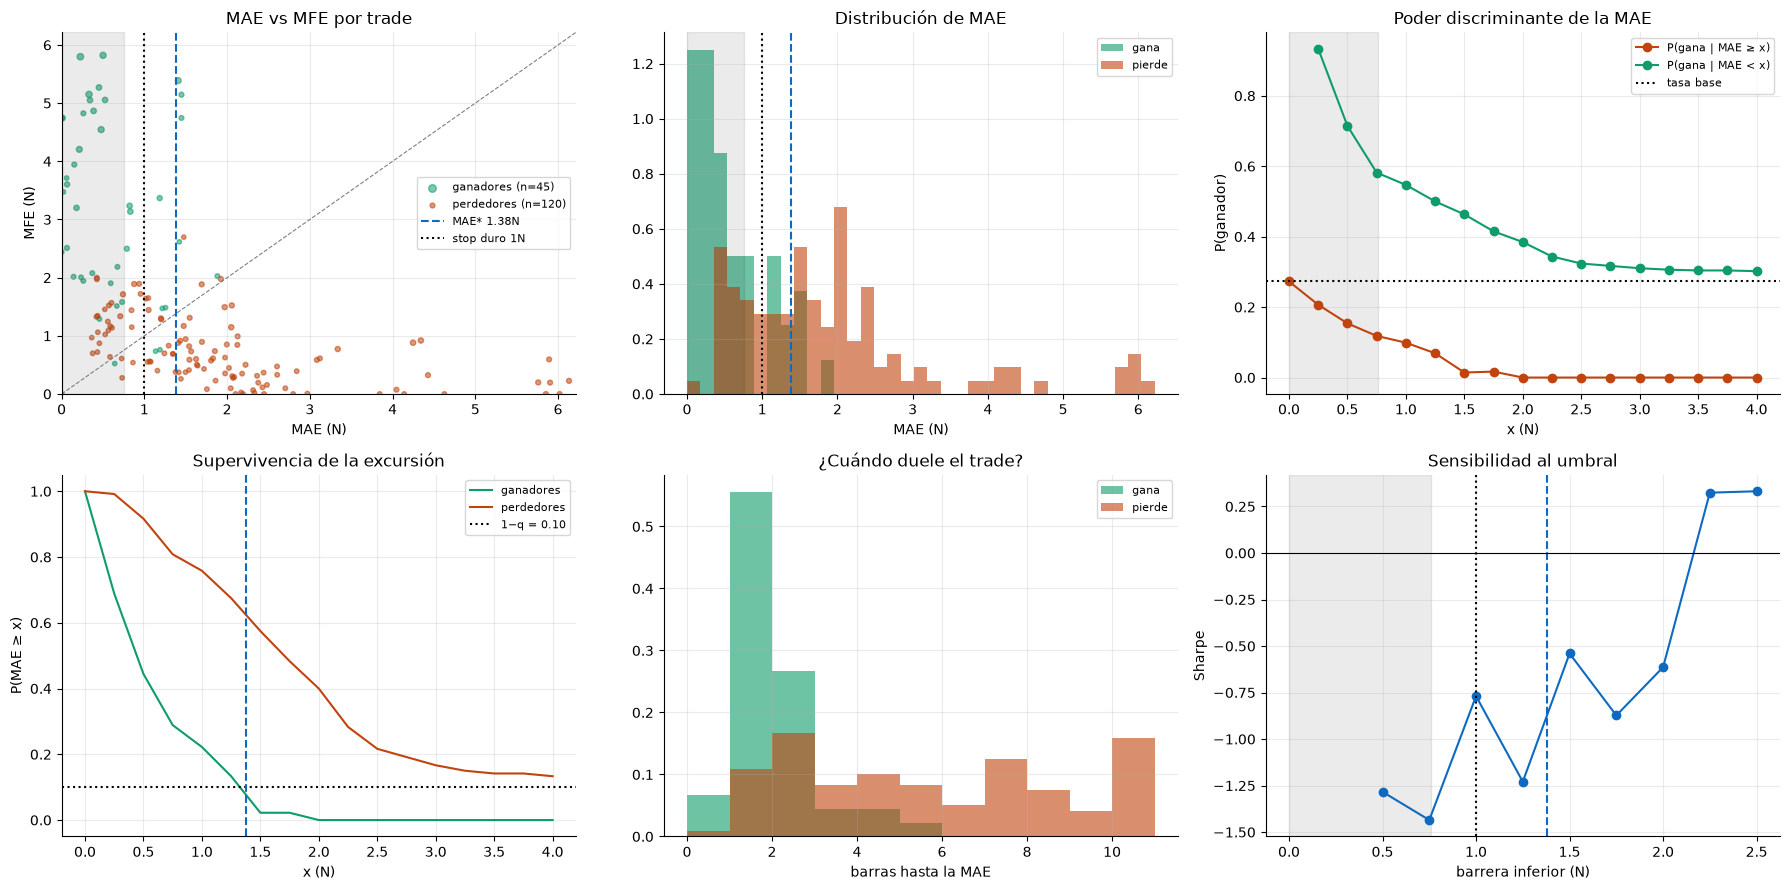

,sn,CAGR,Sharpe,trades,win,resoluble
0,0.500000,-23.3%,-1.28,145,11%,False
1,0.750000,-29.7%,-1.44,135,13%,False
2,1.000000,-25.1%,-0.77,157,20%,True
3,1.250000,-31.5%,-1.23,125,24%,True
4,1.500000,-17.2%,-0.54,149,33%,True
5,1.750000,-27.0%,-0.87,132,31%,True
6,2.000000,-21.9%,-0.61,151,34%,True
7,2.250000,+13.5%,0.32,155,39%,True
8,2.500000,+14.4%,0.33,154,40%,True


In [55]:
# ── Los cinco paneles del análisis MAE ─────────────────────────────────────
fig, ax = plt.subplots(2, 3, figsize=(18, 9))

# (1) MAE vs MFE. La diagonal es E-ratio = 1: por debajo, el trade dio más en
#     contra que a favor antes de resolverse.
for w, c, lab in [(True, "#0e9c6a", "ganadores"), (False, "#c1440e", "perdedores")]:
    d = TR_OBS[TR_OBS.win == w]
    ax[0,0].scatter(d.mae_n, d.mfe_n, s=10 + 40*d.pnl.abs()/max(TR_OBS.pnl.abs().max(), 1e-9),
                    c=c, alpha=.55, label=f"{lab} (n={len(d)})")
_lim = float(np.nanpercentile(np.r_[TR_OBS.mae_n, TR_OBS.mfe_n], 98))
ax[0,0].plot([0, _lim], [0, _lim], lw=.8, c="gray", ls="--")
ax[0,0].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[0,0].axvline(MAE_STAR, ls="--", c="#0e6ac1", label=f"MAE* {MAE_STAR:.2f}N")
ax[0,0].axvline(STOP_N, ls=":", c="k", label=f"stop duro {STOP_N:.0f}N")
ax[0,0].set(xlabel="MAE (N)", ylabel="MFE (N)", xlim=(0, _lim), ylim=(0, _lim),
            title="MAE vs MFE por trade")
ax[0,0].legend(fontsize=8)

# (2) Distribuciones de MAE. La zona sombreada es lo irresoluble.
bins = np.linspace(0, _lim, 36)
ax[0,1].hist(W.mae_n, bins=bins, alpha=.6, density=True, color="#0e9c6a", label="gana")
ax[0,1].hist(L.mae_n, bins=bins, alpha=.6, density=True, color="#c1440e", label="pierde")
ax[0,1].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[0,1].axvline(MAE_STAR, ls="--", c="#0e6ac1"); ax[0,1].axvline(STOP_N, ls=":", c="k")
ax[0,1].set(xlabel="MAE (N)", title="Distribución de MAE"); ax[0,1].legend(fontsize=8)

# (3) LA PUERTA: si esta curva no cae, no hay nada que cortar.
ax[0,2].plot(CUR.x_n, CUR.p_win_ge, "o-", color="#c1440e", label="P(gana | MAE ≥ x)")
ax[0,2].plot(CUR.x_n, CUR.p_win_lt, "o-", color="#0e9c6a", label="P(gana | MAE < x)")
ax[0,2].axhline(TR_OBS.win.mean(), ls=":", c="k", label="tasa base")
ax[0,2].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[0,2].set(xlabel="x (N)", ylabel="P(ganador)", title="Poder discriminante de la MAE")
ax[0,2].legend(fontsize=8)

# (4) Supervivencia: MAE* al cuantil q es donde surv_win = 1−q.
ax[1,0].plot(CUR.x_n, CUR.surv_win, color="#0e9c6a", label="ganadores")
ax[1,0].plot(CUR.x_n, CUR.surv_loss, color="#c1440e", label="perdedores")
ax[1,0].axhline(0.10, ls=":", c="k", label="1−q = 0.10")
ax[1,0].axvline(MAE_STAR, ls="--", c="#0e6ac1")
ax[1,0].set(xlabel="x (N)", ylabel="P(MAE ≥ x)", title="Supervivencia de la excursión")
ax[1,0].legend(fontsize=8)

# (5) Cuándo ocurre la MAE dentro del trade.
ax[1,1].hist(W.bars_to_mae, bins=range(0, MAX_HOLD_BARS+2), alpha=.6, density=True,
             color="#0e9c6a", label="gana")
ax[1,1].hist(L.bars_to_mae, bins=range(0, MAX_HOLD_BARS+2), alpha=.6, density=True,
             color="#c1440e", label="pierde")
ax[1,1].set(xlabel="barras hasta la MAE", title="¿Cuándo duele el trade?")
ax[1,1].legend(fontsize=8)

# (6) Sensibilidad: qué pasa al mover la barrera inferior por toda la banda.
_grid = np.round(np.arange(0.5, 2.51, 0.25), 2)
_rows = []
for _sn in _grid:
    _ec, _tr = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], mae_stop_n=_sn,
                          take_n=TAKE_N, max_hold_bars=MAX_HOLD_BARS,
                          use_donchian_exit=False)
    _m = metrics(_ec, _tr)
    _rows.append({"sn": _sn, "CAGR": _m.get("CAGR", np.nan), "Sharpe": _m.get("Sharpe", np.nan),
                  "trades": len(_tr), "win": _m.get("Win rate", np.nan),
                  "resoluble": _sn >= FLOOR_N})
SENS = pd.DataFrame(_rows)
ax[1,2].plot(SENS.sn, SENS.Sharpe, "o-", color="#0e6ac1")
ax[1,2].axvspan(0, FLOOR_N, color="k", alpha=.08)
ax[1,2].axvline(MAE_STAR, ls="--", c="#0e6ac1"); ax[1,2].axvline(STOP_N, ls=":", c="k")
ax[1,2].axhline(0, lw=.8, c="k")
ax[1,2].set(xlabel="barrera inferior (N)", ylabel="Sharpe",
            title="Sensibilidad al umbral")
plt.tight_layout(); plt.show()

display(SENS.style.format({"CAGR": "{:+.1%}", "Sharpe": "{:.2f}", "win": "{:.0%}"})
        .background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

In [56]:
# ── Veredicto del análisis MAE ─────────────────────────────────────────────
print("="*78); print("  ¿DISCRIMINA LA MAE?"); print("="*78)

_base = TR_OBS.win.mean()
_res = CUR[CUR.x_n >= FLOOR_N]
_lift = float(_res.lift.mean())
_mono = bool((_res.p_win_ge.diff().dropna() <= 1e-9).mean() > 0.75)

print(f"\n  Régimen de calibración         : stop {CALIB_STOP_N:.0f}N, R = {CALIB_STOP_N:.0f}N")
print(f"  Trades / ganadores             : {len(TR_OBS)} / {len(W)}  (tasa base {_base:.1%})")
print(f"  P(gana | MAE ≥ MAE*)           : "
      f"{float(CUR.loc[(CUR.x_n - MAE_STAR).abs().idxmin(), 'p_win_ge']):.1%}")
print(f"  Lift medio en la zona resoluble: {_lift:+.3f}   (negativo = la MAE informa)")
print(f"  Monótona decreciente           : {'sí' if _mono else 'NO'}")
print(f"  Separación KS                  : {float(CUR.ks.max()):.2f}")
print(f"  E-ratio (MFE/MAE)              : {edge_ratio(TR_OBS.mfe_n, TR_OBS.mae_n):.2f}")

if _lift < -0.05 and _mono:
    print("\n  ✓ La MAE SÍ discrimina: la probabilidad de acabar en ganancia cae de forma")
    print("    monótona con la excursión adversa. Cortar por MAE tiene fundamento.")
else:
    print("\n  ✗ La MAE NO discrimina de forma útil. Cualquier umbral aquí solo añadiría")
    print("    coste de transacción.")

# La pregunta que casi ningún análisis de MAE se hace: ¿el umbral que sale de los
# datos cabe DENTRO del stop que se opera, o lo desborda?
print("\n" + "="*78); print("  ¿HAY SITIO PARA UN CIERRE TEMPRANO?"); print("="*78)
print(f"\n  Suelo de resolución  : {FLOOR_N:.2f} N")
print(f"  MAE* calibrado       : {MAE_STAR:.2f} N")
print(f"  MAE p90 de ganadores : {W.mae_n.quantile(.90):.2f} N")

for _lbl, _sn in [("1N (operado hoy)", STOP_N), (f"{CALIB_STOP_N:.0f}N (calibración)", CALIB_STOP_N)]:
    _band_ok = FLOOR_N <= MAE_STAR < _sn
    _mark = "✓ CABE" if _band_ok else "✗ NO CABE"
    print(f"\n  Con stop duro {_lbl:22}: MAE* = {MAE_STAR/_sn:.2f} R   {_mark}")
    if _band_ok:
        print(f"     Banda resoluble para el cierre temprano: "
              f"[{FLOOR_N/_sn:.2f} R, 1.00 R)  →  umbral en {MAE_STAR/_sn:.2f} R")
    else:
        print(f"     MAE* ({MAE_STAR:.2f} N) queda por ENCIMA del stop ({_sn:.0f} N): con esta")
        print(f"     R no hay cierre temprano posible, porque el stop dispara antes.")

print("\n" + "-"*78)
if MAE_STAR < CALIB_STOP_N <= 2.0 and MAE_STAR >= STOP_N:
    print("  LECTURA: el stop de 1N que se opera hoy es MÁS ESTRECHO que la excursión")
    print("  que los ganadores necesitan para resolverse, así que corta ganadores y no")
    print(f"  deja hueco para nada más fino. Ensanchándolo a {CALIB_STOP_N:.0f}N, el mismo")
    print(f"  umbral pasa a valer {MAE_STAR/CALIB_STOP_N:.2f} R y el cierre temprano vuelve")
    print("  a tener sentido: hay distancia entre la barrera interna y la externa.")
    print("  Es el argumento cuantitativo para operar R = 2N y cerrar antes por MAE,")
    print("  en vez de R = 1N sin cierre temprano.")
print(f"\n  Umbral declarado para el vivo (Parte A): {MAE_STOP_N_FIJO:.2f} N = "
      f"{MAE_STOP_N_FIJO/STOP_N:.2f} R sobre stop 1N")

  ¿DISCRIMINA LA MAE?

  Régimen de calibración         : stop 2N, R = 2N
  Trades / ganadores             : 165 / 45  (tasa base 27.3%)
  P(gana | MAE ≥ MAE*)           : 1.4%
  Lift medio en la zona resoluble: -0.355   (negativo = la MAE informa)
  Monótona decreciente           : sí
  Separación KS                  : 0.55
  E-ratio (MFE/MAE)              : 0.90

  ✓ La MAE SÍ discrimina: la probabilidad de acabar en ganancia cae de forma
    monótona con la excursión adversa. Cortar por MAE tiene fundamento.

  ¿HAY SITIO PARA UN CIERRE TEMPRANO?

  Suelo de resolución  : 0.76 N
  MAE* calibrado       : 1.38 N
  MAE p90 de ganadores : 1.35 N

  Con stop duro 1N (operado hoy)      : MAE* = 1.38 R   ✗ NO CABE
     MAE* (1.38 N) queda por ENCIMA del stop (1 N): con esta
     R no hay cierre temprano posible, porque el stop dispara antes.

  Con stop duro 2N (calibración)      : MAE* = 0.69 R   ✓ CABE
     Banda resoluble para el cierre temprano: [0.38 R, 1.00 R)  →  umbral en 0.69 R

-

## 9. Monte Carlo — ¿qué tan afortunada fue esta secuencia?

Remuestreamos los trades **con reemplazo** 5.000 veces. La curva que has visto es *una*
realización de un proceso estocástico; lo relevante es la distribución, no el camino que tocó.

Permutar el orden no sirve: la suma de P&L es invariante y el equity final sale idéntico en
todas las simulaciones. Solo el remuestreo con reemplazo genera una distribución real.

  Simulaciones: 5,000 | Capital inicial: $275,000 | Trades por simulación: 104

  Percentil       Equity final      Max DD
  ----------------------------------------
  p5                   79,930     -72.9%
  p25                 132,401     -55.6%
  p50                 172,646     -43.1%
  p75                 212,655     -32.2%
  p95                 277,938     -19.1%

  Prob. de terminar en pérdida : 94.6%
  Prob. de DD ≥ 50% (bust)     : 34.6%
  Peor caso simulado           : $-23,559 (DD -108.6%)


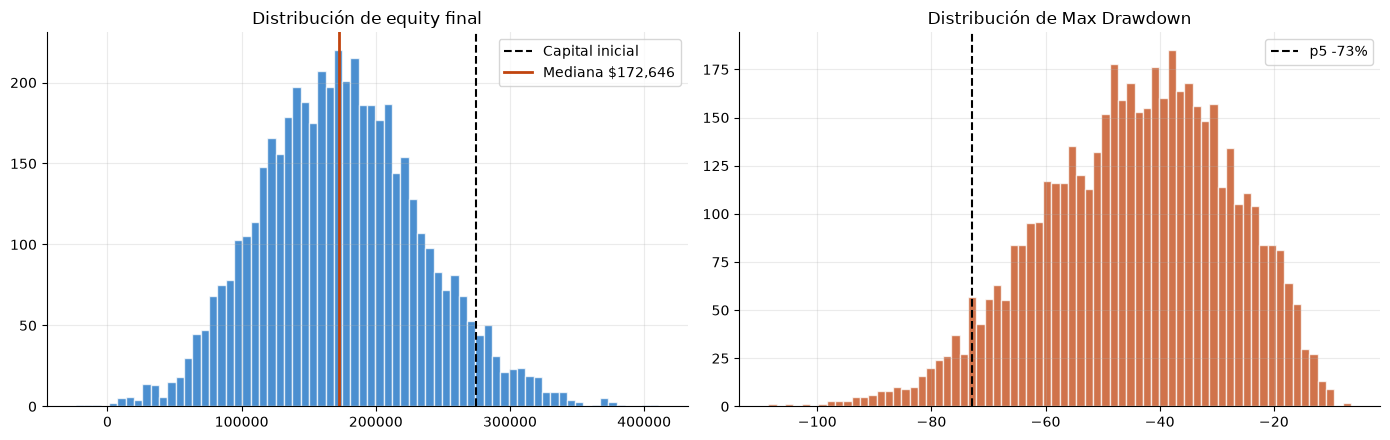

In [57]:
def mc_trades(trades, n_sims=5000, eq0=EQUITY_0, bust=-0.50, seed=7):
    """Bootstrap CON REEMPLAZO del P&L de los trades."""
    if trades is None or not len(trades):
        return None
    pnl = trades.pnl.values
    if len(pnl) < 10:
        return None
    rng = np.random.default_rng(seed)
    finals, dds, busts = [], [], 0
    for _ in range(n_sims):
        p = rng.choice(pnl, size=len(pnl), replace=True)
        eq = eq0 + np.cumsum(p)
        full = np.concatenate([[eq0], eq])
        peak = np.maximum.accumulate(full)
        dd = ((full - peak)/peak).min()
        finals.append(eq[-1]); dds.append(dd)
        if dd <= bust:
            busts += 1
    return {"finals": np.array(finals), "dds": np.array(dds), "p_bust": busts/n_sims}

mc = mc_trades(tr_s2)
if not mc:
    print(f"  Solo {len(tr_s2)} trades cerrados: menos de 10 no dan distribución. "
          "Alarga la muestra o baja BAR_SIZE.")
else:
    f, d = mc["finals"], mc["dds"]
    print(f"  Simulaciones: 5,000 | Capital inicial: ${EQUITY_0:,} | "
          f"Trades por simulación: {len(tr_s2)}\n")
    print(f"  {'Percentil':<12}{'Equity final':>16}{'Max DD':>12}")
    print(f"  {'-'*40}")
    for q in [5, 25, 50, 75, 95]:
        print(f"  p{q:<11}{np.percentile(f,q):>15,.0f}{np.percentile(d,q):>11.1%}")
    print(f"\n  Prob. de terminar en pérdida : {(f < EQUITY_0).mean():.1%}")
    print(f"  Prob. de DD ≥ 50% (bust)     : {mc['p_bust']:.1%}")
    print(f"  Peor caso simulado           : ${f.min():,.0f} (DD {d.min():.1%})")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
    ax[0].hist(f, bins=70, color="#0e6ac1", alpha=.75, edgecolor="w")
    ax[0].axvline(EQUITY_0, color="k", ls="--", label="Capital inicial")
    ax[0].axvline(np.median(f), color="#c1440e", lw=2, label=f"Mediana ${np.median(f):,.0f}")
    ax[0].set_title("Distribución de equity final"); ax[0].legend()
    ax[1].hist(d*100, bins=70, color="#c1440e", alpha=.75, edgecolor="w")
    ax[1].axvline(np.percentile(d, 5)*100, color="k", ls="--",
                  label=f"p5 {np.percentile(d,5):.0%}")
    ax[1].set_title("Distribución de Max Drawdown"); ax[1].legend()
    plt.tight_layout(); plt.show()

## 10. Tabla comparativa y veredicto

In [58]:
cols = ["CAGR", "Volatilidad", "Sharpe", "Sortino", "Max DD", "Calmar", "Retorno total"]
_rows = {
    f"Turtle Sys1 ({SYS1['entry']}/{SYS1['exit']})":  metrics(ec_s1, tr_s1),
    f"Turtle Sys2 ({SYS2['entry']}/{SYS2['exit']})":  metrics(ec_s2, tr_s2),
    "Turtle Sys2 long-only":                          metrics(ec_s2lo, tr_s2lo),
    f"B&H {_bh_sym}":                                 metrics(bh),
}
if len(EC_WFO):
    _rows["Walk-Forward OOS"] = metrics(EC_WFO)

comp = pd.DataFrame(_rows).T.reindex(columns=cols)
display(comp.style.format({c: "{:.2%}" for c in
                           ["CAGR", "Volatilidad", "Max DD", "Retorno total"]}
        | {c: "{:.2f}" for c in ["Sharpe", "Sortino", "Calmar"]})
        .background_gradient(subset=["Sharpe", "Calmar"], cmap="RdYlGn"))

_tag = f"{'_'.join(RAW)}_{BAR_SIZE.replace(' ','')}"
comp.to_csv(OUT / f"turtle_ibkr_{_tag}_resultados.csv")
if len(FOLDS):
    FOLDS.to_csv(OUT / f"turtle_ibkr_{_tag}_walkforward_folds.csv", index=False)
if len(tr_s2):
    tr_s2.to_csv(OUT / f"turtle_ibkr_{_tag}_trades.csv", index=False)
SPECS_DF.to_csv(OUT / f"turtle_ibkr_{_tag}_specs.csv", index=False)
print(f"\n✓ Exportado a {OUT}/ con prefijo turtle_ibkr_{_tag}_")

,CAGR,Volatilidad,Sharpe,Sortino,Max DD,Calmar,Retorno total
Turtle Sys1 (20/10),-38.05%,37.08%,-1.03,-0.71,-54.73%,-0.70,-45.44%
Turtle Sys2 (55/20),-31.50%,33.70%,-0.93,-0.52,-45.18%,-0.70,-37.64%
Turtle Sys2 long-only,22.88%,40.92%,0.56,0.39,-41.65%,0.55,29.33%
B&H MBT,-13.20%,41.66%,-0.32,-0.39,-54.06%,-0.24,-17.21%
Walk-Forward OOS,-5.93%,58.63%,-0.10,-0.07,-57.48%,-0.10,-4.44%



✓ Exportado a /Users/diegoochoa/Projects/qsCrypto/output/ con prefijo turtle_ibkr_MBT_BRR_30mins_


In [59]:
print("="*74)
print("  CHECKLIST DE VALIDEZ — responde SÍ a todo antes de arriesgar capital")
print("="*74)

_wins = int((FOLDS.OOS_ret > FOLDS.BASE_ret).sum()) if len(FOLDS) else 0
_p = p if len(FOLDS) > 1 else 1.0
_m_wfo = metrics(EC_WFO) if len(EC_WFO) else {}
_exec_ratio = (REJ_S2["ejecutadas"] /
               max(REJ_S2["ejecutadas"] + REJ_S2["qty_cero"] + REJ_S2["apalancamiento"]
                   + REJ_S2["limite_direccion"] + REJ_S2["limite_grupo"], 1))

chk = [
    ("Muestra ≥ 2 años de histórico", _span_days/365.25 >= 2),
    ("≥ 8 folds OOS (el t-test tiene potencia)", len(FOLDS) >= 8),
    ("≥ 30 trades cerrados en el baseline", len(tr_s2) >= 30),
    ("≥ 50% de las señales fueron ejecutables (contratos enteros)", _exec_ratio >= 0.50),
    ("WFO supera al canónico fijo en >60% de folds",
     (_wins/len(FOLDS) > 0.60) if len(FOLDS) else False),
    ("Diferencia WFO vs canónico estadísticamente significativa", _p < 0.05),
    ("Parámetros estables entre folds (moda >50%)",
     (FOLDS.p_entry.value_counts().iloc[0]/len(FOLDS) > 0.50) if len(FOLDS) else False),
    ("Edge sobrevive el escenario pesimista de costes", bool(cost_df.CAGR.iloc[3] > 0)),
    ("Top-3 trades <50% del P&L total",
     bool(len(tr) >= 3 and tot and tr.pnl.head(3).sum()/tot < 0.50)),
    ("Nº efectivo de apuestas independientes ≥ 8", n_eff >= 8),
    ("Sharpe OOS > Sharpe de B&H", _m_wfo.get("Sharpe", 0) > metrics(bh).get("Sharpe", 0)),
    ("Prob. Monte Carlo de bust (DD≥50%) < 20%", (mc["p_bust"] < 0.20) if mc else False),
]
for txt, ok in chk:
    print(f"  [{'✓' if ok else '✗'}] {txt}")

n_ok = sum(bool(o) for _, o in chk)
print(f"\n  {n_ok}/{len(chk)} criterios superados")
print(f"\n  {'→ Sigue investigando, pero hay algo.' if n_ok >= 9 else '→ NO despliegues capital. El backtest no soporta el peso.'}")
print("="*74)
print("\n  Nota: el criterio de n_eff ≥ 8 es IMPOSIBLE de superar con uno o dos")
print("  contratos del mismo subyacente. No es un fallo del backtest: es la razón")
print("  por la que el sistema Turtle se diseñó como cartera y no como estrategia")
print("  de un solo mercado. Si quieres el sistema completo, el universo del")
print("  notebook Turtle_WalkForward_Diversified.ipynb es el punto de partida.")

  CHECKLIST DE VALIDEZ — responde SÍ a todo antes de arriesgar capital
  [✗] Muestra ≥ 2 años de histórico
  [✗] ≥ 8 folds OOS (el t-test tiene potencia)
  [✓] ≥ 30 trades cerrados en el baseline
  [✗] ≥ 50% de las señales fueron ejecutables (contratos enteros)
  [✓] WFO supera al canónico fijo en >60% de folds
  [✗] Diferencia WFO vs canónico estadísticamente significativa
  [✗] Parámetros estables entre folds (moda >50%)
  [✗] Edge sobrevive el escenario pesimista de costes
  [✓] Top-3 trades <50% del P&L total
  [✗] Nº efectivo de apuestas independientes ≥ 8
  [✓] Sharpe OOS > Sharpe de B&H
  [✗] Prob. Monte Carlo de bust (DD≥50%) < 20%

  4/12 criterios superados

  → NO despliegues capital. El backtest no soporta el peso.

  Nota: el criterio de n_eff ≥ 8 es IMPOSIBLE de superar con uno o dos
  contratos del mismo subyacente. No es un fallo del backtest: es la razón
  por la que el sistema Turtle se diseñó como cartera y no como estrategia
  de un solo mercado. Si quieres el siste

## 11. Libro abierto al final de la simulación

El motor devuelve `(curva, trades CERRADOS)`: las posiciones vivas en la última barra no
aparecen en ninguna de las dos. Se reejecuta el Sistema 2 con `open_book` para capturarlas. Su
P&L es **no realizado** —marcado al último cierre, no a un fill— y no descuenta la comisión de
salida.

In [60]:
BOOK = {}
_ec_s2, _tr_s2 = run_turtle(DATA_S2, SYS2["entry"], SYS2["exit"], open_book=BOOK)

ASOF = BOOK["asof"]
pnl_hist = tr_s2.groupby("symbol").pnl.sum() if len(tr_s2) else pd.Series(dtype=float)

rows = []
for s, p in BOOK["positions"].items():
    mult = SPECS[s]["multiplier"]
    px   = BOOK["last_close"][s]
    qty  = pos_qty(p)
    avg  = pos_cost(p)/qty if qty else np.nan
    upnl = p["side"] * (px*qty - pos_cost(p)) * mult      # bruto, sin comisión de salida
    rows.append({
        "symbol": s, "grupo": SYM2GROUP.get(s, "otro"),
        "lado": "LARGO" if p["side"] > 0 else "CORTO",
        "unidades": pos_nu(p), "contratos": qty,
        "precio_medio": avg, "ultimo_cierre": px,
        "notional": qty*px*mult, "stop": p["stop"],
        "dist_stop_N": abs(px - p["stop"])/p["n_entry"] if p["n_entry"] else np.nan,
        "N_entrada": p["n_entry"], "abierta": p["opened"],
        "horas": (ASOF - p["opened"]).total_seconds()/3600,
        "pnl_no_realizado": upnl,
        "riesgo_al_stop": abs(px - p["stop"])*qty*mult,
        "pnl_realizado_hist": float(pnl_hist.get(s, 0.0)),
    })

POSICIONES = pd.DataFrame(rows)
if len(POSICIONES):
    POSICIONES = POSICIONES.sort_values("pnl_no_realizado", ascending=False).reset_index(drop=True)

cash   = BOOK["cash"]
upnl_t = POSICIONES.pnl_no_realizado.sum() if len(POSICIONES) else 0.0
gross  = POSICIONES.notional.sum() if len(POSICIONES) else 0.0
eq_mtm = cash + upnl_t

print("="*78)
print(f"  LIBRO ABIERTO — Sistema 2 ({SYS2['entry']}/{SYS2['exit']}) @ {BAR_SIZE}, "
      f"al {ASOF:%Y-%m-%d %H:%M}")
print("="*78)
print(f"  Posiciones abiertas   : {len(POSICIONES)}")
print(f"  Unidades              : {POSICIONES.unidades.sum() if len(POSICIONES) else 0}"
      f"  (tope dirección {MAX_DIR_UNITS}, grupo {MAX_CORR_UNITS})")
print(f"  Contratos             : {POSICIONES.contratos.sum() if len(POSICIONES) else 0}")
print(f"  Nocional bruto        : ${gross:,.0f}   "
      f"({gross/eq_mtm:.2f}x equity, tope {MAX_GROSS_LEV}x)" if eq_mtm else "")
print(f"  Equity realizado      : ${cash:,.0f}")
print(f"  P&L no realizado      : ${upnl_t:,.0f}")
print(f"  Equity marcado        : ${eq_mtm:,.0f}   (= curva: ${ec_s2.iloc[-1]:,.0f})")
print(f"  P&L realizado acumul. : ${tr_s2.pnl.sum() if len(tr_s2) else 0:,.0f} "
      f"en {len(tr_s2)} trades cerrados")

if len(POSICIONES):
    display(POSICIONES.style.format({
        "contratos": "{:,.0f}", "precio_medio": "{:,.2f}", "ultimo_cierre": "{:,.2f}",
        "notional": "${:,.0f}", "stop": "{:,.2f}", "dist_stop_N": "{:.2f}N",
        "N_entrada": "{:,.2f}", "abierta": "{:%Y-%m-%d %H:%M}", "horas": "{:,.1f}",
        "pnl_no_realizado": "${:,.0f}", "riesgo_al_stop": "${:,.0f}",
        "pnl_realizado_hist": "${:,.0f}",
    }).background_gradient(subset=["pnl_no_realizado"], cmap="RdYlGn"))
    POSICIONES.to_csv(OUT / f"turtle_ibkr_{_tag}_posiciones.csv", index=False)
    print(f"\n✓ Exportado: turtle_ibkr_{_tag}_posiciones.csv")
else:
    print("\n  Sin posiciones abiertas al cierre de la simulación.")

  LIBRO ABIERTO — Sistema 2 (55/20) @ 30 mins, al 2026-09-04 20:00
  Posiciones abiertas   : 0
  Unidades              : 0  (tope dirección 12, grupo 6)
  Contratos             : 0
  Nocional bruto        : $0   (0.00x equity, tope 4.0x)
  Equity realizado      : $171,488
  P&L no realizado      : $0
  Equity marcado        : $171,488   (= curva: $171,488)
  P&L realizado acumul. : $-101,330 en 104 trades cerrados

  Sin posiciones abiertas al cierre de la simulación.


In [61]:
# Cerrar la sesión: TWS mantiene el clientId ocupado y el siguiente `connect()`
# con el mismo id falla mientras el socket siga vivo.
if IBS is not None and IBS.isConnected():
    IBS.disconnect()
    print("Sesión IBKR cerrada.")

---

## Cómo cambiar de granularidad

Solo hay dos celdas que tocar, ambas en §1:

| Objetivo | `BAR_SIZE` | `LOOKBACK_DAYS` | Nota |
|---|---|---|---|
| Tendencia clásica | `"1 day"` | `365*5` | El régimen para el que Turtle fue diseñado. |
| Swing intradía | `"1 hour"` | `365*2` | ~5.700 barras/año; canales de 55h ≈ una semana. |
| Intradía rápido | `"5 mins"` | `180` | El coste por round-trip empieza a dominar. |
| Microestructura | `"1 secs"` | `30` | IB solo sirve ~6 meses; §1.2 avisa de que esto ya no es tendencia. |

Todo lo demás —troceado de peticiones, anualización, ventanas de walk-forward, avisos de
coherencia— se recalcula solo a partir de `BAR_SIZE` y de los datos efectivamente descargados.

**Para cambiar de contrato:** `SYMBOLS = ["BRR"]` en §2, y comprueba la celda de viabilidad de
capital de §3 — con `EQUITY_0 = 100.000` y BTC por encima de 80k, un solo contrato de BRR
(5 BTC) supera el tope de apalancamiento y el sistema no entrará nunca.

## Qué NO hace este notebook

- **No ajusta el roll.** La serie continua se usa tal cual la sirve IB; §8 mide el sesgo pero no
  lo corrige. Un ajuste hacia atrás (*back-adjusted*) cambiaría los niveles de precio y con
  ellos los canales Donchian de todo el histórico.
- **No modela el margen.** El tope de apalancamiento bruto es un proxy; el margen inicial y de
  mantenimiento del CME varía con la volatilidad y puede forzar liquidaciones que el motor no
  simula.
- **No usa datos intrabarra.** La prelación stop-sobre-canal es una suposición pesimista,
  no una reconstrucción de lo que ocurrió dentro de la barra.
- **No es ejecución.** No hay órdenes, ni parciales, ni rechazos: los fills se asumen al precio
  de disparo más el slippage configurado.